##1. Импорт библиотек

In [123]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, label_binarize

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv1D,
    Dense,
    Dropout,
    Flatten,
    GRU,
    Input,
    MaxPooling1D
)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

warnings.filterwarnings('ignore')
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.layers import GRU, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [124]:
SEED = 11
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

##2. Загрузка данных

In [125]:
# Загрузка данных с GitHub
csv_url = "https://raw.githubusercontent.com/Daria-Chernykh/iad-course-project/main/MKA_04.2015_unlabeled.csv"
df_features = pd.read_csv(csv_url)

xls_url = "https://raw.githubusercontent.com/Daria-Chernykh/iad-course-project/main/MKA_TMI_labels.xls"
df_labels = pd.read_excel(xls_url)

print("Размер df_features:", df_features.shape)
print("Размер df_labels:", df_labels.shape)

Размер df_features: (15243, 49)
Размер df_labels: (2679, 50)


##3. Первичный анализ данных

###3.1 Просмотр первых строк

In [126]:
print("Первые строки df_features:")
display(df_features.head())

print("\nПервые строки df_labels:")
display(df_labels.head())

Первые строки df_features:


,"Ubs,V","Ibs,A","Isun,A","Ipt1,A","Ipt2,A","Ipt3,A","Ipt4,A","Ipt5,A","Ipt6,A","Ipt7,A","Ipt10,A","Ipt11,A","Ipt12,A","Ipt13,A","Ipt14,A","Ipt15,A","Ipt16,A","Ipt17,A","TR1,C","TR2,C","TR3,C","TR4,C","TR5,C","TR6,C","TR7,C","TR8,C","TR9,C","TR10,C","TR11,C","TR12,C","TR13,C","TR14,C","TR15,C","TR16,C","TDS1,C","TDS2,C","TDS3,C","TDS4,C","TDS5,C","TDS6,C","TDS7,C","TDS8,C","TDS9,C","TKpt,C","TGbv,C","TNap,C","TPrd2,C","TPrd1,C","TDS24,C"
0,13.12,1.41,0.99,0.07,1.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,22.0,4.0,2.0,3.0,5.0,1.0,1.0,0.0,-1.0,-17.0,6.0,2.0,6.0,2.0,3.0,16.0,16.0,16.0,16.0,16.0,15.0,20.0,19.0,18.0,26.0,20.0,19.0,30.0,20.0,21.0
1,13.12,1.44,1.09,0.07,1.20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,22.0,4.0,2.0,4.0,5.0,2.0,2.0,0.0,-1.0,-17.0,9.0,2.0,6.0,4.0,2.0,16.0,16.0,16.0,16.0,16.0,15.0,21.0,20.0,18.0,26.0,20.0,19.0,31.0,20.0,21.0
2,13.25,0.27,1.44,0.09,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,24.0,4.0,2.0,4.0,5.0,2.0,2.0,1.0,-1.0,-12.0,9.0,4.0,8.0,4.0,5.0,16.0,16.0,16.0,16.0,16.0,15.0,21.0,20.0,18.0,26.0,20.0,19.0,31.0,20.0,21.0
3,13.32,0.27,0.88,0.07,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,24.0,4.0,2.0,4.0,5.0,2.0,2.0,1.0,0.0,-9.0,8.0,4.0,8.0,5.0,5.0,16.0,16.0,16.0,16.0,16.0,15.0,21.0,20.0,19.0,26.0,20.0,19.0,27.0,20.0,21.0
4,13.38,0.21,0.80,0.09,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,24.0,4.0,4.0,4.0,5.0,4.0,4.0,1.0,0.0,-9.0,9.0,2.0,9.0,5.0,5.0,15.0,16.0,16.0,16.0,16.0,15.0,20.0,20.0,19.0,26.0,20.0,19.0,25.0,20.0,21.0



Первые строки df_labels:


,"Ubs,V","Ibs,A","Isun,A","Ipt1,A","Ipt2,A","Ipt3,A","Ipt4,A","Ipt5,A","Ipt6,A","Ipt7,A","Ipt10,A","Ipt11,A","Ipt12,A","Ipt13,A","Ipt14,A","Ipt15,A","Ipt16,A","Ipt17,A","TR1,C","TR2,C","TR3,C","TR4,C","TR5,C","TR6,C","TR7,C","TR8,C","TR9,C","TR10,C","TR11,C","TR12,C","TR13,C","TR14,C","TR15,C","TR16,C","TDS1,C","TDS2,C","TDS3,C","TDS4,C","TDS5,C","TDS6,C","TDS7,C","TDS8,C","TDS9,C","TKpt,C","TGbv,C","TNap,C","TPrd2,C","TPrd1,C","TDS24,C",Class
0,14.83,0.24,0.91,0.09,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21,19,16,14,6,8,14,17,13,11,25.0,9,17,19,18,19,18,18,18,18,18,18,17,17,17,25,17,16,18,18,21,0
1,14.76,0.21,0.27,0.07,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21,20,16,15,6,8,14,17,13,12,25.0,9,17,20,18,19,18,18,18,18,18,18,17,17,17,25,17,16,18,18,21,0
2,14.83,0.24,0.61,0.09,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21,19,16,15,6,10,14,17,14,12,25.0,11,17,20,20,18,18,18,18,18,18,18,17,17,17,25,17,17,18,18,21,0
3,14.83,0.21,0.51,0.07,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21,19,17,15,7,10,14,17,14,12,22.0,11,18,20,20,19,18,18,18,18,18,18,17,17,17,25,17,17,18,18,21,0
4,14.83,0.21,0.35,0.07,0.09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21,19,17,15,7,10,15,17,14,13,24.0,11,18,20,20,21,18,18,18,18,18,18,18,18,17,25,17,17,18,18,21,0


По результатам просмотра первых строк можно сделать следующие выводы:
- Данные представляют собой числовые признаки телеметрии малого космического аппарата (ТМИ).
- Названия признаков имеют инженерный характер (например, Ubs_V, Ibs_A, TR1_C и т.д.), что соответствует показаниям различных датчиков.
- В наборе df_features отсутствует столбец с метками классов — это неразмеченные данные.
- В наборе df_labels присутствуют те же признаки, а также дополнительный столбец **Class**, который содержит метки классов.
- Структура признаков в df_features и df_labels совпадает (одинаковые названия столбцов признаков).
- Значения признаков имеют различный масштаб (например, напряжения, токи, температуры), что требует последующей нормализации или стандартизации.

Таким образом, df_labels содержит размеченную часть данных, а df_features — полный (в том числе неразмеченный) набор телеметрии.

###3.2 Информация о данных

In [127]:
print("Информация о df_features:")
df_features.info()

print("\nИнформация о df_labels:")
df_labels.info()

Информация о df_features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15243 entries, 0 to 15242
Data columns (total 49 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ubs,V    15243 non-null  float64
 1   Ibs,A    15243 non-null  float64
 2   Isun,A   15243 non-null  float64
 3   Ipt1,A   15243 non-null  float64
 4   Ipt2,A   15243 non-null  float64
 5   Ipt3,A   15243 non-null  float64
 6   Ipt4,A   15243 non-null  float64
 7   Ipt5,A   15243 non-null  float64
 8   Ipt6,A   15243 non-null  float64
 9   Ipt7,A   15243 non-null  float64
 10  Ipt10,A  15243 non-null  float64
 11  Ipt11,A  15243 non-null  float64
 12  Ipt12,A  15243 non-null  float64
 13  Ipt13,A  15243 non-null  float64
 14  Ipt14,A  15243 non-null  float64
 15  Ipt15,A  15243 non-null  float64
 16  Ipt16,A  15243 non-null  float64
 17  Ipt17,A  15243 non-null  float64
 18  TR1,C    15243 non-null  float64
 19  TR2,C    15243 non-null  float64
 20  TR3,C    15243 non-null 

- Размер набора df_features: 15243 объектов и 49 признаков.
- Размер набора df_labels: 2679 объектов и 50 столбцов (49 признаков + 1 целевой признак Class).
- Все признаки в df_features имеют тип float64, пропуски отсутствуют.
- В df_labels признаки представлены типами float64 и int64, также отсутствуют пропуски.
- Столбец Class в df_labels является целевым признаком и содержит целочисленные метки классов.
- Количество объектов в df_labels значительно меньше, чем в df_features, что указывает на наличие неразмеченных данных.

Таким образом:
- df_labels — размеченная подвыборка данных;
- df_features — полный набор, содержащий как размеченные, так и неразмеченные данные.

Это подтверждает постановку задачи с частично размеченными данными, где неразмеченная часть будет использоваться для предобучения (автокодировщик), а размеченная — для обучения классификатора.

###3.3 Проверка пропусков

In [128]:
print("Пропуски в df_features:")
print(df_features.isna().sum())

print("\nПропуски в df_labels:")
print(df_labels.isna().sum())

Пропуски в df_features:
Ubs,V      0
Ibs,A      0
Isun,A     0
Ipt1,A     0
Ipt2,A     0
Ipt3,A     0
Ipt4,A     0
Ipt5,A     0
Ipt6,A     0
Ipt7,A     0
Ipt10,A    0
Ipt11,A    0
Ipt12,A    0
Ipt13,A    0
Ipt14,A    0
Ipt15,A    0
Ipt16,A    0
Ipt17,A    0
TR1,C      0
TR2,C      0
TR3,C      0
TR4,C      0
TR5,C      0
TR6,C      0
TR7,C      0
TR8,C      0
TR9,C      0
TR10,C     0
TR11,C     0
TR12,C     0
TR13,C     0
TR14,C     0
TR15,C     0
TR16,C     0
TDS1,C     0
TDS2,C     0
TDS3,C     0
TDS4,C     0
TDS5,C     0
TDS6,C     0
TDS7,C     0
TDS8,C     0
TDS9,C     0
TKpt,C     0
TGbv,C     0
TNap,C     0
TPrd2,C    0
TPrd1,C    0
TDS24,C    0
dtype: int64

Пропуски в df_labels:
Ubs,V      0
Ibs,A      0
Isun,A     0
Ipt1,A     0
Ipt2,A     0
Ipt3,A     0
Ipt4,A     0
Ipt5,A     0
Ipt6,A     0
Ipt7,A     0
Ipt10,A    0
Ipt11,A    0
Ipt12,A    0
Ipt13,A    0
Ipt14,A    0
Ipt15,A    0
Ipt16,A    0
Ipt17,A    0
TR1,C      0
TR2,C      0
TR3,C      0
TR4,C      0
TR5,C      0
TR6,

Проверка данных показала, что:

- В наборе df_features отсутствуют пропущенные значения.
- В наборе df_labels также отсутствуют пропущенные значения.

Таким образом, этап обработки пропусков не требуется, что упрощает дальнейшую предобработку данных.

###3.4 Анализ распределения классов

Уникальные классы:
[0 2 1]

Распределение классов:


,count
Class,
0,2356
1,218
2,105


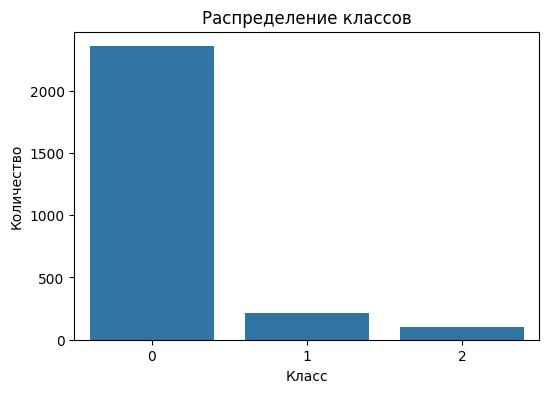

In [129]:
label_column = 'Class'

print("Уникальные классы:")
print(df_labels[label_column].unique())

print("\nРаспределение классов:")
display(df_labels[label_column].value_counts())

# Визуализация
plt.figure(figsize=(6,4))
sns.countplot(x=df_labels[label_column])
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.show()

Анализ распределения классов показал:

- В данных присутствуют три класса:
  - 0 — штатное функционирование,
  - 1 — отказ,
  - 2 — сбой.

- Распределение классов:
  - класс 0: 2356 объектов,
  - класс 1: 218 объектов,
  - класс 2: 105 объектов.

- Наблюдается сильный дисбаланс классов:
  - класс 0 существенно преобладает,
  - классы 1 и 2 представлены значительно меньшим количеством наблюдений.

Таким образом, задача является несбалансированной классификацией.

В связи с этим при обучении моделей необходимо:
- использовать дополнительные метрики качества (balanced accuracy, F1-score, ROC-AUC),
- учитывать влияние дисбаланса на обучение модели.


###3.5 Описательная статистика признаков

In [130]:
display(df_labels.describe())

,"Ubs,V","Ibs,A","Isun,A","Ipt1,A","Ipt2,A","Ipt3,A","Ipt4,A","Ipt5,A","Ipt6,A","Ipt7,A","Ipt10,A","Ipt11,A","Ipt12,A","Ipt13,A","Ipt14,A","Ipt15,A","Ipt16,A","Ipt17,A","TR1,C","TR2,C","TR3,C","TR4,C","TR5,C","TR6,C","TR7,C","TR8,C","TR9,C","TR10,C","TR11,C","TR12,C","TR13,C","TR14,C","TR15,C","TR16,C","TDS1,C","TDS2,C","TDS3,C","TDS4,C","TDS5,C","TDS6,C","TDS7,C","TDS8,C","TDS9,C","TKpt,C","TGbv,C","TNap,C","TPrd2,C","TPrd1,C","TDS24,C",Class
count,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000
mean,14.088903,0.681149,0.744246,0.301657,0.304169,0.205778,0.200642,0.213050,0.433966,0.297014,0.186779,0.289802,0.282926,0.189832,0.283315,0.259804,0.204991,0.279854,0.503546,7.933184,1.952594,-7.485629,-13.387085,-1.259425,-9.490482,13.365435,-6.296379,-11.068682,-14.196529,-9.178052,-3.419186,-2.555804,17.204927,-7.496081,7.983949,11.107130,7.045913,6.346398,7.080254,7.112355,7.630459,6.649496,6.974617,14.153789,7.681971,6.961553,8.724151,16.663307,21.181038,0.159761
std,1.077994,1.078681,0.997524,0.806005,0.792725,0.783437,0.778907,0.824493,1.154981,1.132852,0.752707,1.126208,1.107992,0.755061,1.106091,1.046427,0.789265,1.081491,70.319498,46.403284,41.904934,65.901859,60.141176,34.053470,60.783844,38.238253,53.541873,59.411205,69.937326,55.388815,52.242349,58.280820,24.863725,63.832362,32.595470,21.536657,35.650591,37.482964,36.485113,34.907149,35.802703,38.207669,37.629271,39.712017,37.849951,38.326742,37.459169,12.043739,12.584964,0.461199
min,0.130000,0.110000,0.000000,0.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-257.000000,-257.000000,-235.000000,-236.000000,-235.000000,-228.000000,-234.000000,-225.000000,-228.000000,-233.000000,-255.000000,-253.000000,-257.000000,-250.000000,-257.000000,-256.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,-128.000000,0.000000
25%,14.100000,0.210000,0.000000,0.070000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,19.000000,7.000000,5.000000,0.000000,2.000000,2.000000,5.000000,3.000000,0.000000,-26.000000,3.000000,4.000000,6.000000,7.000000,2.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,16.000000,16.000000,16.000000,24.000000,17.000000,17.000000,17.000000,17.000000,20.000000,0.000000
50%,14.500000,0.240000,0.450000,0.070000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,20.000000,13.000000,11.000000,4.000000,7.000000,8.000000,12.000000,7.000000,5.000000,11.000000,6.000000,10.000000,12.000000,13.000000,10.000000,16.000000,16.000000,17.000000,17.000000,17.000000,16.000000,17.000000,17.000000,17.000000,25.000000,18.000000,18.000000,19.000000,19.000000,21.000000,0.000000
75%,14.690000,0.270000,1.070000,0.090000,0.090000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,22.000000,17.000000,17.000000,7.000000,10.000000,14.000000,18.000000,13.000000,11.000000,25.000000,9.000000,17.000000,20.000000,18.000000,18.000000,17.000000,17.000000,17.000000,17.000000,18.000000,17.000000,19.000000,19.000000,18.000000,26.000000,19.000000,19.000000,20.000000,20.000000,21.000000,0.000000


Анализ статистических характеристик признаков показал:

- Все признаки являются числовыми и имеют различный масштаб значений.
- Значения признаков существенно различаются по диапазону:
  - токи (Ibs_A, Ipt*_A) принимают значения преимущественно в диапазоне [0, 5],
  - напряжения (Ubs_V) — в диапазоне [0.13, 15.68],
  - температуры (TR*_C, TDS*_C) — в широком диапазоне от -257 до +148.
- Для ряда признаков наблюдаются отрицательные значения:
  - минимальные значения температур достигают -257°C,
  - минимальные значения TDS признаков составляют -128°C,
  что значительно ниже физически возможных значений и может быть связано с особенностями кодирования телеметрии (например, отсутствие сигнала или ошибка датчика).
- Средние значения и стандартные отклонения значительно различаются между признаками:
  - наименьшая вариативность у напряжения (σ≈1.08),
  - наибольшая вариативность у температурных признаков (σ до 70),
  что подтверждает разнородность данных (разные физические величины: токи, напряжения, температуры и др.).
- Распределения признаков имеют выраженную асимметрию:
  - большинство токовых признаков имеют медиану = 0,
  - температурные признаки демонстрируют бимодальные распределения (наличие как положительных, так и отрицательных значений).

Таким образом, признаки имеют различный масштаб, распределение и природу, что требует обязательного применения методов масштабирования (например, стандартизации или нормализации) перед обучением нейросетевых моделей. Наличие аномальных отрицательных значений (кодов ошибок) требует сохранения исходных значений, так как они несут важную диагностическую информацию.

###3.6 Визуализация распределений признаков

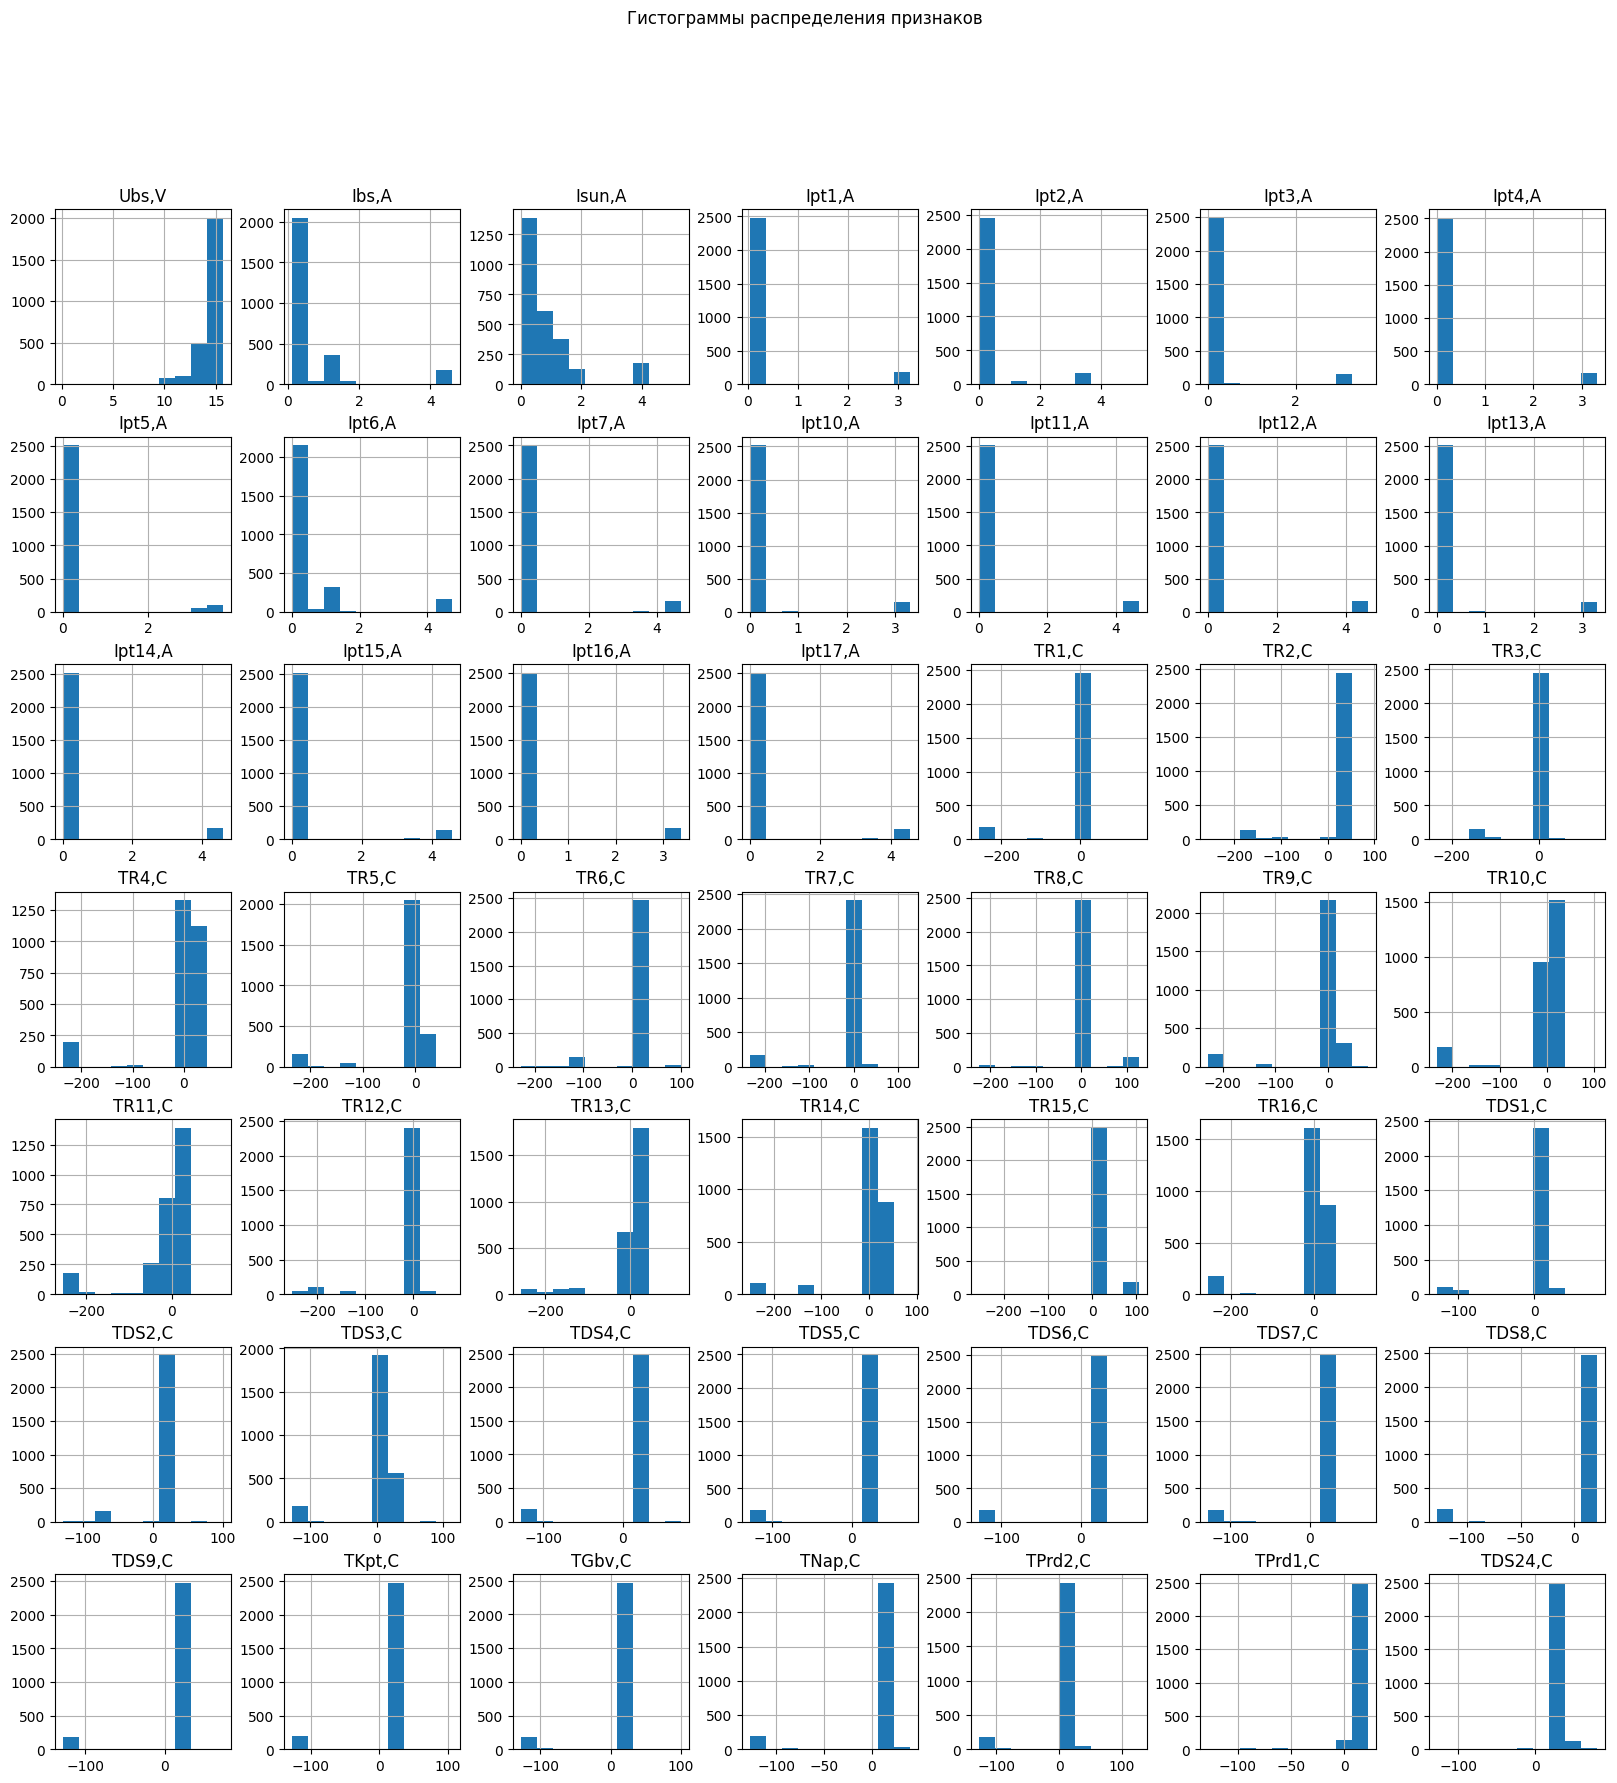

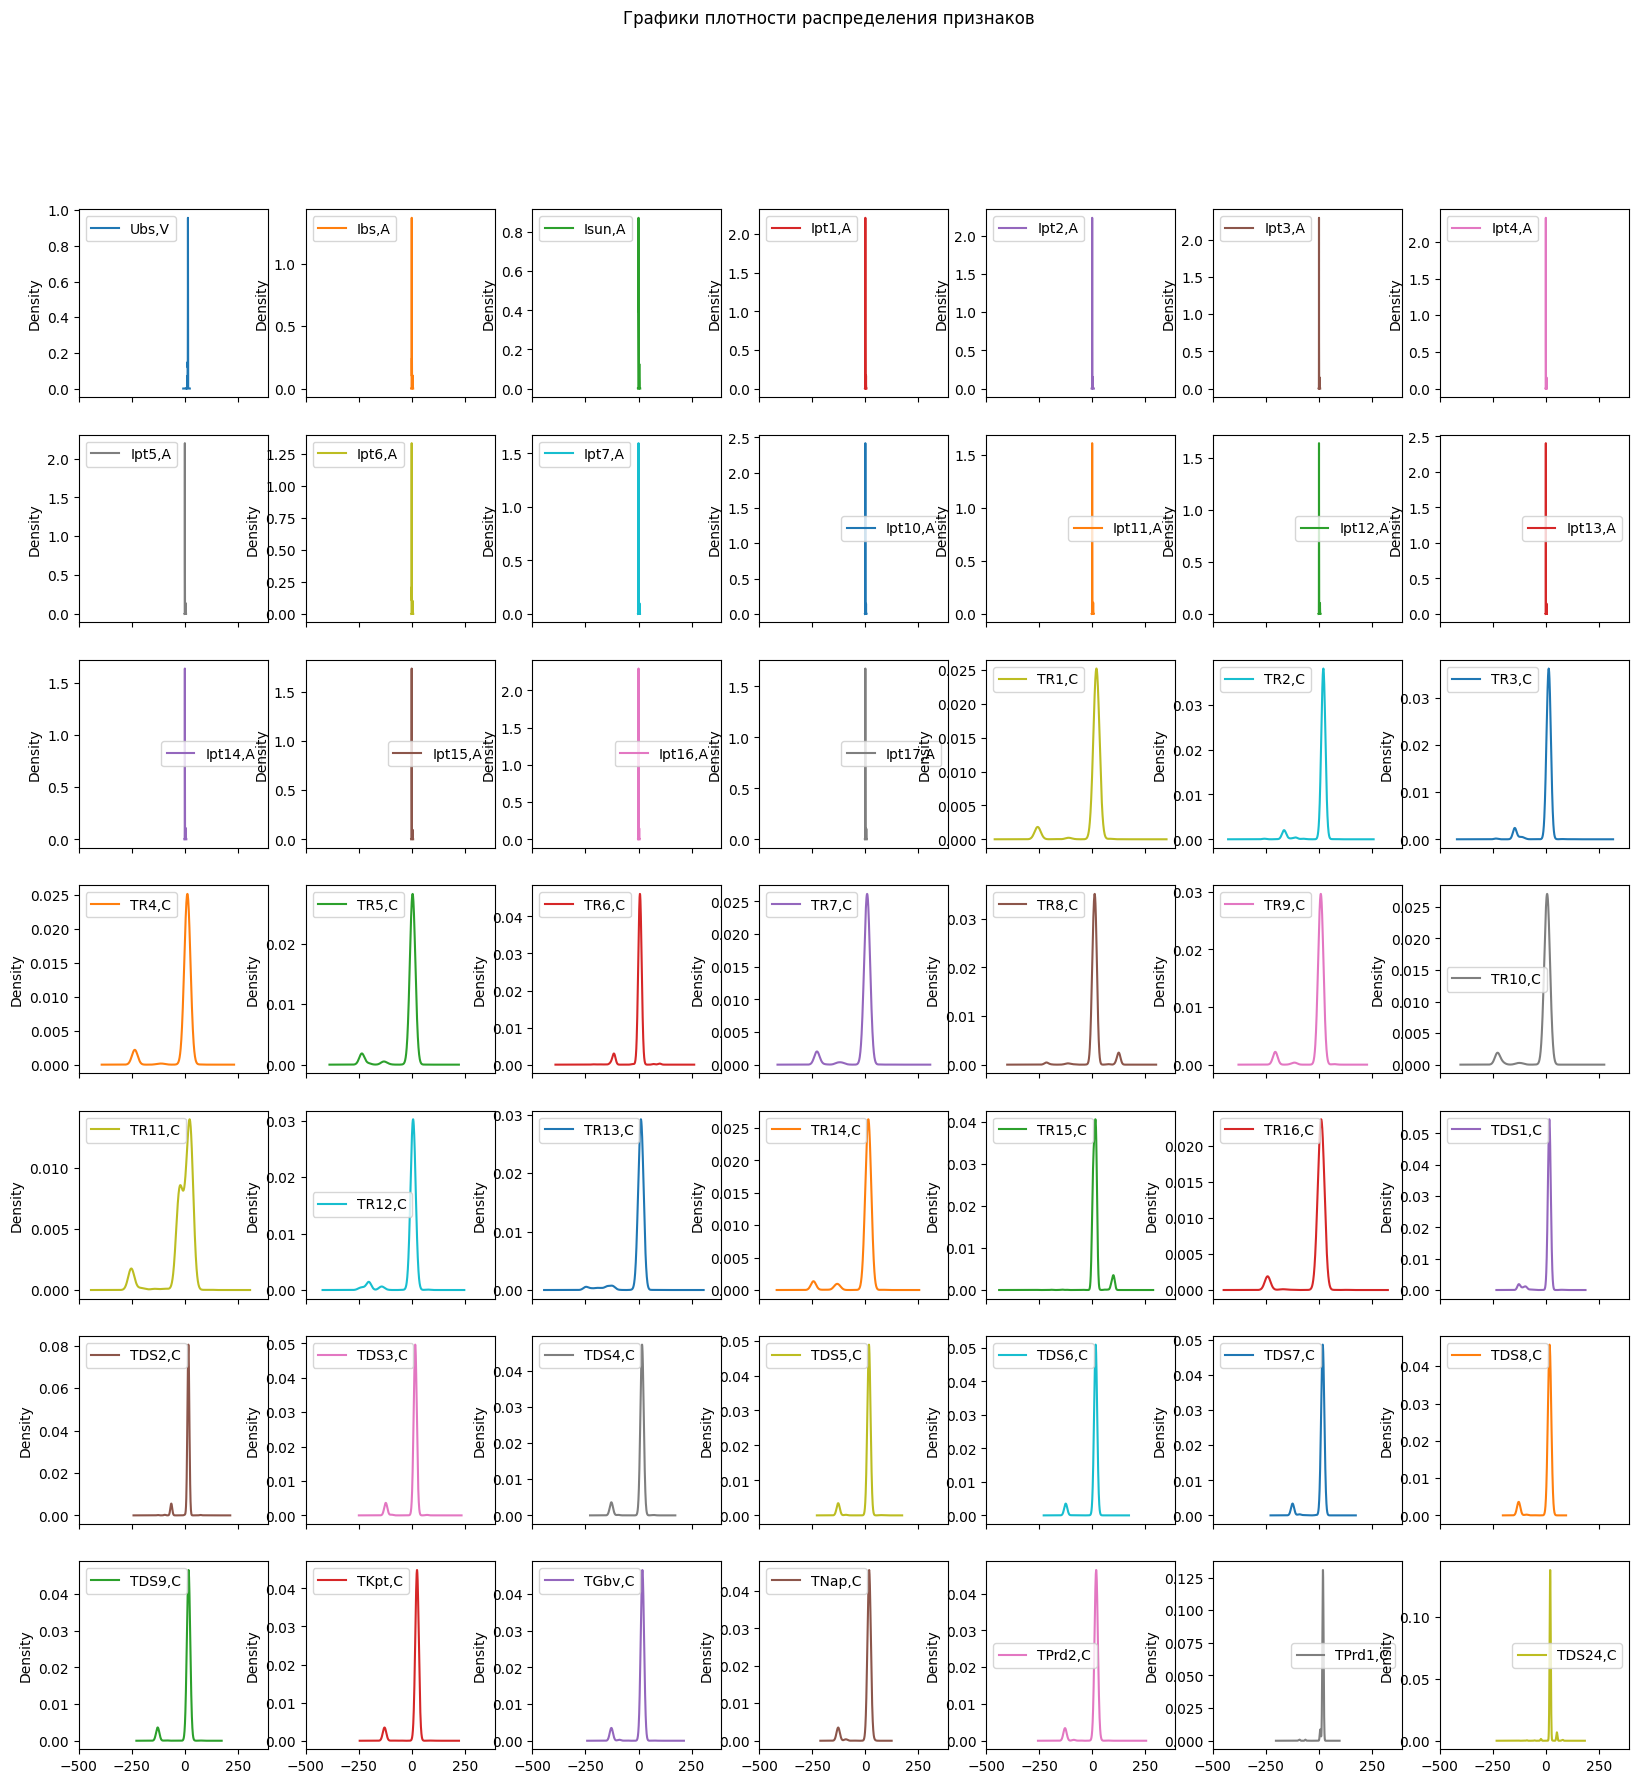

In [131]:
# Гистограммы
X_for_vis = df_labels.drop(columns=['Class'])
X_for_vis.hist(figsize=(20,20))
plt.suptitle("Гистограммы распределения признаков")
plt.show()

# Графики плотности
X_for_vis.plot(kind='density', subplots=True, layout=(7,7), figsize=(20,20))
plt.suptitle("Графики плотности распределения признаков")
plt.show()

Анализ гистограмм и графиков плотности показал:

**Форма распределений:**
- Большинство признаков имеют сильно скошенные распределения:
  - для токовых признаков (Ipt*_A) наблюдается высокая концентрация значений вблизи нуля,
  - при этом присутствуют редкие большие значения (выбросы) до 5.24 А,
  - медианные значения многих токовых признаков равны 0, что указывает на их неактивное состояние в большинстве режимов.

**Дискретность и квантование:**
- Для ряда признаков (особенно температурных) распределения имеют дискретный характер,
- На гистограммах видны отдельные "столбцы" вместо непрерывного распределения,
- что может быть связано с особенностями измерения, квантованием сигналов или фиксированными шагами квантования телеметрии.

**Режимность работы системы:**
- На графиках плотности заметны узкие пики, что указывает на повторяющиеся значения,
- Это свидетельствует о наличии фиксированных режимов работы космического аппарата,
- Многие признаки имеют несколько характерных значений (модальных), соответствующих различным состояниям системы.

**Аномальные коды:**
- В некоторых признаках присутствуют аномальные значения:
  - для температурных признаков (TR*_C): значения около -257°C, -256°C, -235°C,
  - для признаков TDS*_C: значения -128°C,
  - что значительно ниже физически возможных температур и, вероятно, соответствует специальным кодам (отсутствие сигнала, ошибка датчика, калибровочные значения).

**Разнообразие типов распределений:**
- Признаки можно условно разделить на группы с характерными распределениями:
  1. Токовые признаки (Ipt*_A): распределения с пиком в нуле и положительными выбросами
  2. Напряжения (Ubs_V): распределения, близкие к нормальным
  3. Температурные признаки (TR*_C, TDS*_C): бимодальные распределения с отрицательными и положительными значениями

Таким образом, распределения признаков являются неоднородными, содержат выбросы, имеют дискретную структуру и не соответствуют нормальному распределению, что необходимо учитывать при предобработке данных. Наличие специальных кодов (аномальных значений) требует сохранения исходных значений, так как они несут важную диагностическую информацию о состоянии датчиков.

###3.7 Корреляционный анализ

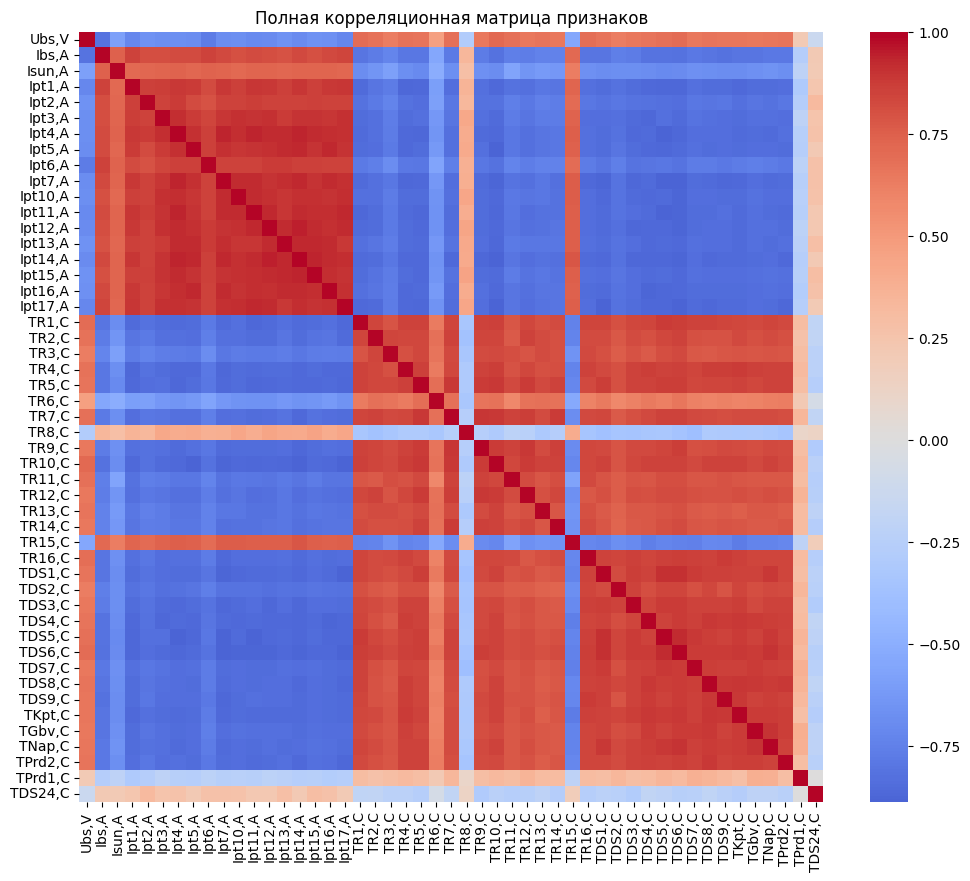

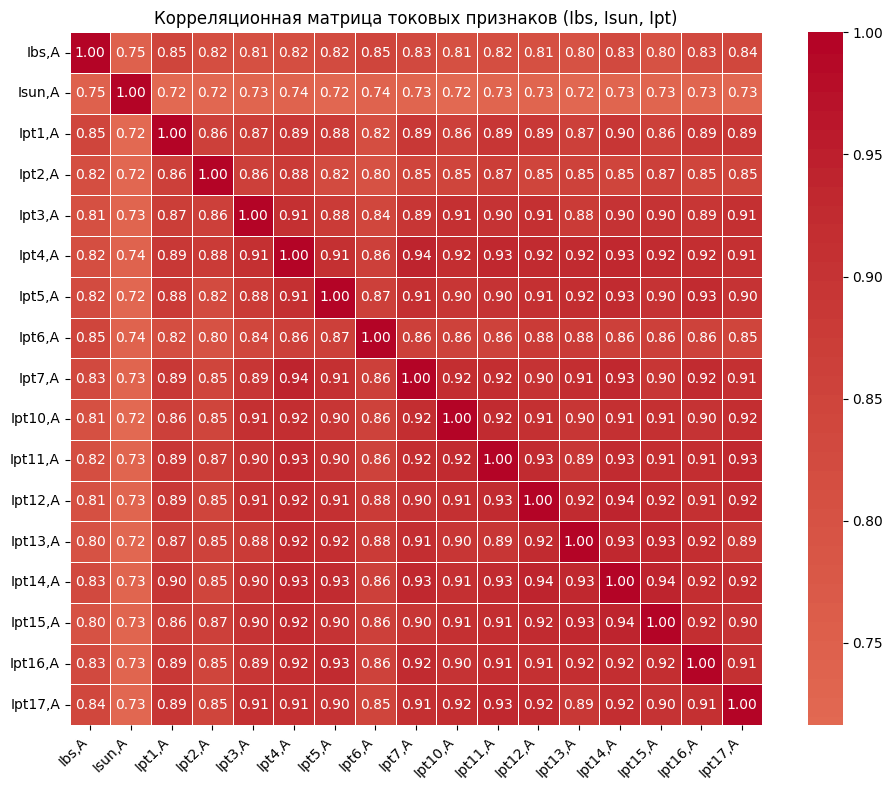

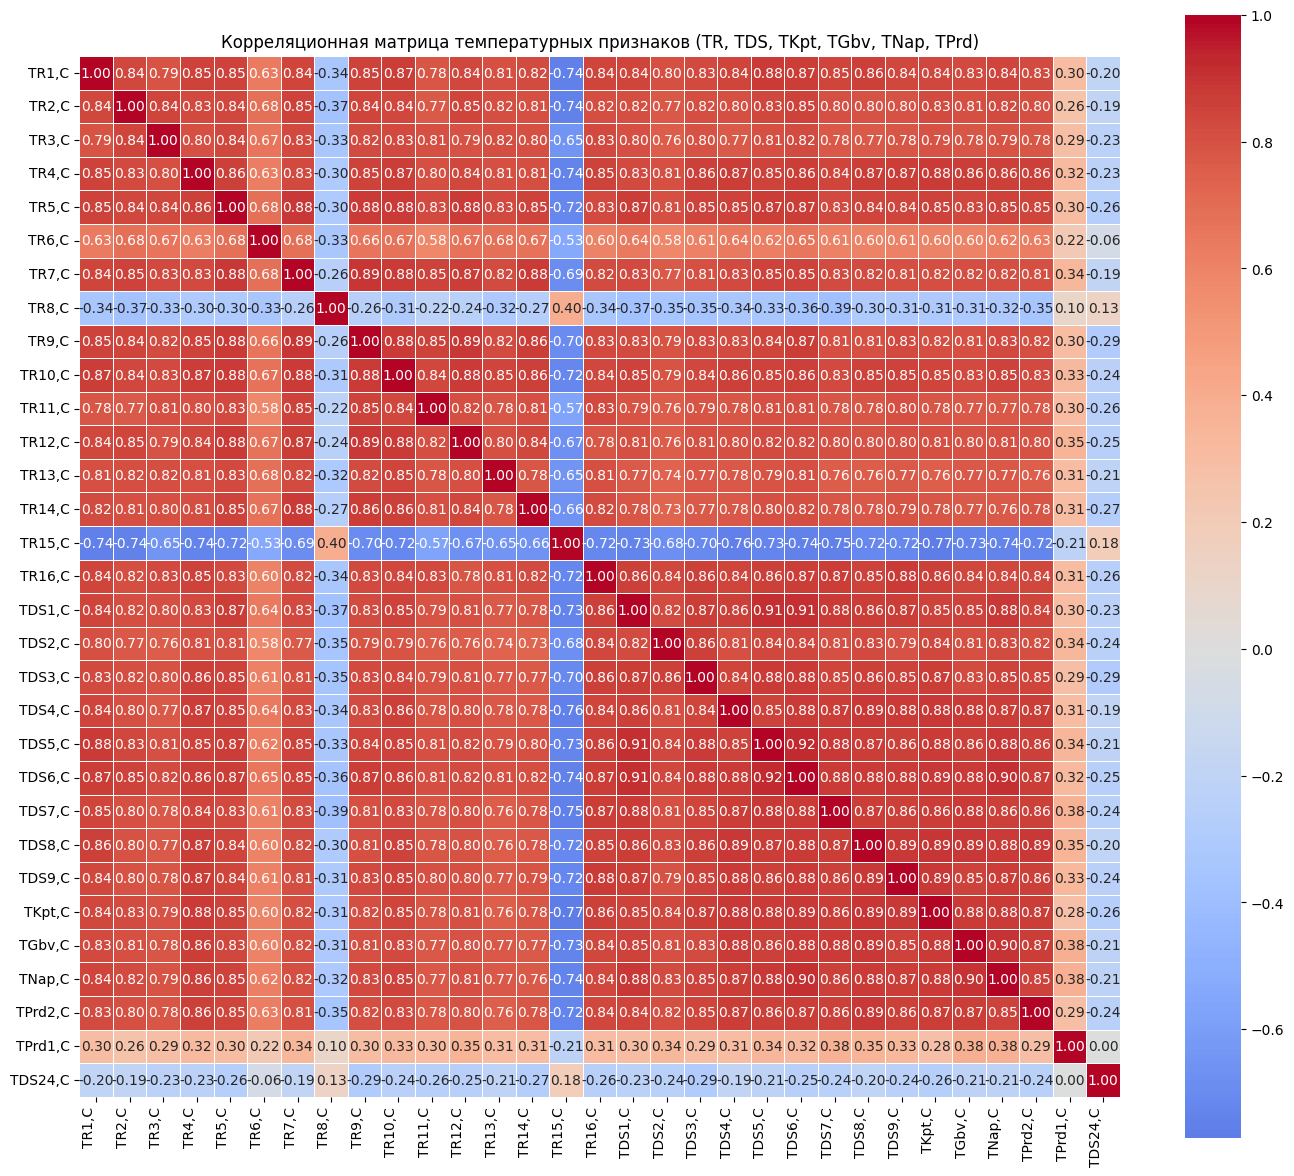

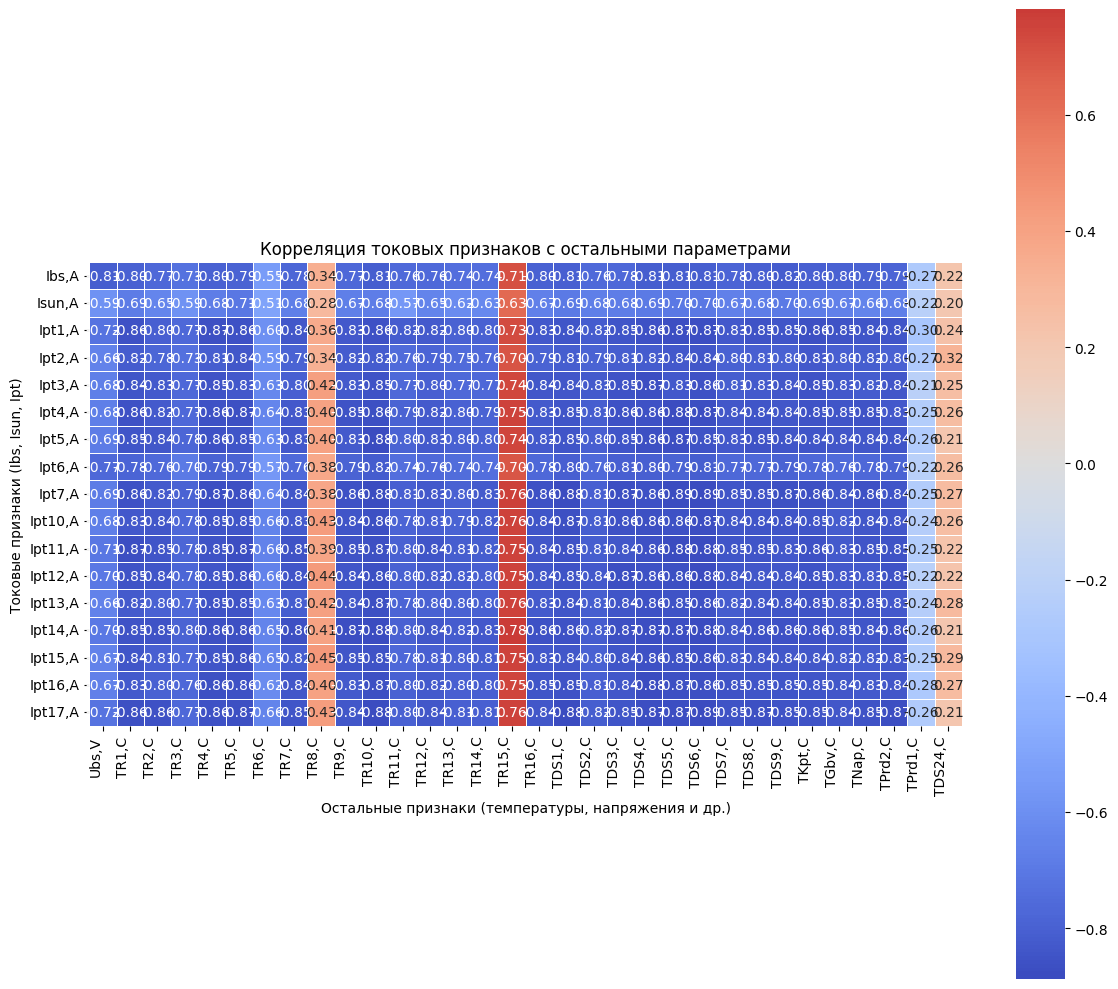

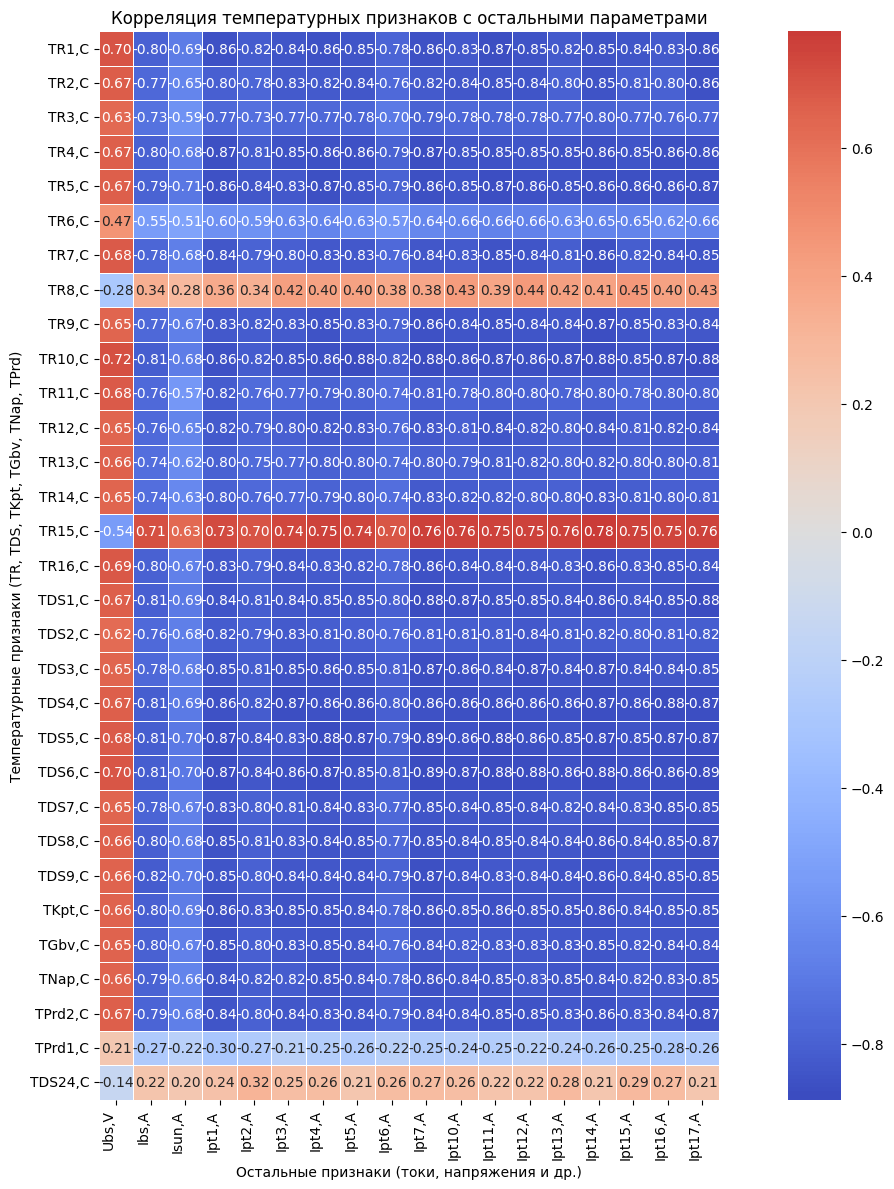

In [132]:
# Списки признаков по группам
current_features = ['Ibs,A', 'Isun,A', 'Ipt1,A', 'Ipt2,A', 'Ipt3,A', 'Ipt4,A', 'Ipt5,A',
                    'Ipt6,A', 'Ipt7,A', 'Ipt10,A', 'Ipt11,A', 'Ipt12,A', 'Ipt13,A',
                    'Ipt14,A', 'Ipt15,A', 'Ipt16,A', 'Ipt17,A']

temperature_features = ['TR1,C', 'TR2,C', 'TR3,C', 'TR4,C', 'TR5,C', 'TR6,C', 'TR7,C',
                        'TR8,C', 'TR9,C', 'TR10,C', 'TR11,C', 'TR12,C', 'TR13,C',
                        'TR14,C', 'TR15,C', 'TR16,C', 'TDS1,C', 'TDS2,C', 'TDS3,C',
                        'TDS4,C', 'TDS5,C', 'TDS6,C', 'TDS7,C', 'TDS8,C', 'TDS9,C',
                        'TKpt,C', 'TGbv,C', 'TNap,C', 'TPrd2,C', 'TPrd1,C', 'TDS24,C']

# Проверяем, какие признаки из списков действительно присутствуют в данных
available_current = [f for f in current_features if f in df_labels.columns]
available_temp = [f for f in temperature_features if f in df_labels.columns]

# Полная корреляционная матрица
plt.figure(figsize=(12,10))
corr_matrix_full = df_labels.drop(columns=['Class']).corr()
sns.heatmap(corr_matrix_full, cmap='coolwarm', center=0)
plt.title("Полная корреляционная матрица признаков")
plt.show()

# 1. Матрица корреляций для токовых признаков
if len(available_current) > 0:
    plt.figure(figsize=(10,8))
    corr_matrix_current = df_labels[available_current].corr()
    sns.heatmap(corr_matrix_current, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title("Корреляционная матрица токовых признаков (Ibs, Isun, Ipt)")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Токовые признаки не найдены в данных")

# 2. Матрица корреляций для температурных признаков
if len(available_temp) > 0:
    plt.figure(figsize=(14,12))
    corr_matrix_temp = df_labels[available_temp].corr()
    sns.heatmap(corr_matrix_temp, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title("Корреляционная матрица температурных признаков (TR, TDS, TKpt, TGbv, TNap, TPrd)")
    plt.xticks(rotation=90, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Температурные признаки не найдены в данных")

# 3. Матрица корреляций токовых признаков со всеми остальными (включая температурные)
if len(available_current) > 0:
    # Определяем все остальные признаки (исключая токовые и Class)
    non_current_features = [col for col in df_labels.columns
                           if col not in available_current and col != 'Class']

    if len(non_current_features) > 0:
        plt.figure(figsize=(12, 10))
        # Берём корреляцию между токовыми и всеми остальными признаками
        corr_current_with_others = df_labels[available_current + non_current_features].corr()
        # Выделяем только часть матрицы: токовые признаки vs остальные
        corr_current_vs_others = corr_current_with_others.loc[available_current, non_current_features]

        sns.heatmap(corr_current_vs_others, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    square=True, linewidths=0.5)
        plt.title("Корреляция токовых признаков с остальными параметрами")
        plt.xlabel("Остальные признаки (температуры, напряжения и др.)")
        plt.ylabel("Токовые признаки (Ibs, Isun, Ipt)")
        plt.xticks(rotation=90, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print("Нет других признаков для анализа")

# 4. Матрица корреляций температурных признаков со всеми остальными (включая токовые)
if len(available_temp) > 0:
    # Определяем все остальные признаки (исключая температурные и Class)
    non_temp_features = [col for col in df_labels.columns
                        if col not in available_temp and col != 'Class']

    if len(non_temp_features) > 0:
        plt.figure(figsize=(14, 12))
        # Берём корреляцию между температурными и всеми остальными признаками
        corr_temp_with_others = df_labels[available_temp + non_temp_features].corr()
        # Выделяем только часть матрицы: температурные признаки vs остальные
        corr_temp_vs_others = corr_temp_with_others.loc[available_temp, non_temp_features]

        sns.heatmap(corr_temp_vs_others, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    square=True, linewidths=0.5)
        plt.title("Корреляция температурных признаков с остальными параметрами")
        plt.xlabel("Остальные признаки (токи, напряжения и др.)")
        plt.ylabel("Температурные признаки (TR, TDS, TKpt, TGbv, TNap, TPrd)")
        plt.xticks(rotation=90, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print("Нет других признаков для анализа")

Для детального анализа структуры взаимосвязей между признаками были построены:

- полная корреляционная матрица всех признаков;

- матрица корреляций для группы токовых параметров (Ibs,A, Isun,A, Ipt1,A, ..., Ipt17,A);

- матрица корреляций для группы температурных параметров (TR1,C, TR2,C, ..., TR16,C, TDS1,C, ..., TDS9,C, TKpt,C, TGbv,C, TNap,C, TPrd2,C, TPrd1,C, TDS24,C);

- матрицы межгрупповой корреляции: токовые признаки со всеми остальными, температурные признаки со всеми остальными.

Анализ полной корреляционной матрицы:

- Признаки образуют выраженную блочную структуру, что указывает на принадлежность к разным подсистемам космического аппарата.

- Чётко выделяются два крупных блока: токовые признаки (Ibs, Isun, Ipt) и температурные признаки (TR, TDS, TKpt, TGbv, TNap, TPrd).

- Внутри каждого блока наблюдается высокая положительная корреляция (значения близки к 0.8–0.9), что свидетельствует о согласованной работе параметров внутри одной подсистемы.

Анализ внутригрупповых корреляций:

- Токовые признаки: практически все пары признаков имеют корреляцию выше 0.7, многие — выше 0.9. Это объясняется тем, что токи в различных каналах электропитания изменяются согласованно в зависимости от режима работы аппарата. Высокая избыточность в этой группе может указывать на возможность сокращения числа признаков без существенной потери информации.

- Температурные признаки: также демонстрируют высокую положительную корреляцию внутри группы, особенно между датчиками, расположенными в близких зонах аппарата. Это связано с едиными тепловыми процессами и общими режимами терморегулирования.

Анализ межгрупповой корреляции:

- Корреляция между токовыми и температурными признаками значительно слабее: большинство коэффициентов находятся в диапазоне от –0.3 до 0.3, что свидетельствует об относительной независимости электрических и тепловых процессов.

- Наиболее заметные корреляции наблюдаются между отдельными токовыми каналами и температурными датчиками, связанными с критическими узлами (например, TR5_C, TR7_C, TR13_C), что может отражать тепловыделение при работе соответствующих потребителей электроэнергии.

- Слабая межгрупповая корреляция подтверждает, что токи и температуры отражают разные физические процессы и разные подсистемы космического аппарата.

Выводы:

- Данные обладают выраженной структурой зависимостей: высокая внутригрупповая корреляция и слабая межгрупповая.

- Высокая корреляция внутри групп может приводить к избыточности информации, однако для нейросетевых моделей это не является критическим ограничением, так как они способны автоматически извлекать значимые зависимости.

- Слабая связь между группами указывает на то, что использование как токовых, так и температурных признаков в модели может дать синергетический эффект, поскольку они дополняют друг друга, отражая различные аспекты работы аппарата.

###3.8 Корреляция с целевым признаком

In [133]:
corr_with_target = df_labels.corr()['Class'].sort_values(ascending=False)
display(corr_with_target)

,Class
Class,1.000000
"Ipt1,A",0.520780
"Ipt3,A",0.485096
"Ipt16,A",0.480947
"Ipt4,A",0.476128
"Ipt7,A",0.475100
"Ipt14,A",0.473560
"Ipt17,A",0.471052
"Ipt2,A",0.469668
"Ipt11,A",0.468986


Анализ корреляции признаков с целевым признаком показал:

- Наиболее сильную положительную корреляцию с целевым признаком имеют признаки:
  - Ipt1_A (≈ 0.52),
  - Ipt3_A (≈ 0.49),
  - Ipt16_A (≈ 0.48),
  - Ipt4_A, Ipt7_A, Ipt14_A (≈ 0.47).

- Эти признаки относятся к группе токов (обозначение Ipt), что указывает на их значимую роль в определении технического состояния аппарата.

- Значительная часть признаков имеет отрицательную корреляцию с целевым признаком:
  - например, TR7_C (≈ -0.61),
  - TR5_C, TR12_C, TR13_C (≈ -0.60),
  - TR10_C (≈ -0.57).

- Эти признаки, вероятно, относятся к температурным параметрам, что также свидетельствует об их влиянии на состояние системы.

- В целом наблюдается умеренная корреляция признаков с целевым признаком (|r| < 0.7), что указывает на отсутствие сильной линейной зависимости.

Таким образом, зависимость между признаками и целевым признаком является сложной и нелинейной, что обосновывает использование нейросетевых моделей для решения задачи классификации.

##4. Подготовка размеченного набора

###4.1 Выделение признаков и целевой переменной

In [134]:
X_labeled = df_labels.drop(columns=['Class'])
y_labeled = df_labels['Class']

print("Размер X_labeled:", X_labeled.shape)
print("Размер y_labeled:", y_labeled.shape)

Размер X_labeled: (2679, 49)
Размер y_labeled: (2679,)


Размеченный набор данных сформирован на основе df_labels.

- В качестве признаков используется матрица X_labeled, содержащая все признаки телеметрии.
- В качестве целевой переменной используется столбец Class (y_labeled).

Размер размеченного набора:
- X_labeled: 2679 объектов и 49 признаков,
- y_labeled: 2679 меток классов.

###4.2 Проверка структуры признаков

In [135]:
print("Совпадают ли признаки:", list(X_labeled.columns) == list(df_features.columns))

Совпадают ли признаки: True


Проверка показала, что структура признаков в df_labels и df_features совпадает.

Это означает, что оба набора данных описывают объекты одной природы (телеметрические параметры).

##5. Подготовка неразмеченного набора

In [136]:
X_unlabeled = df_features.copy()
print("Размер X_unlabeled:", X_unlabeled.shape)

Размер X_unlabeled: (15243, 49)


Неразмеченный набор данных сформирован на основе df_features.

Он содержит полный набор телеметрических данных (15243 объекта) без меток классов.

Данный набор будет использоваться для предобучения автокодировщика.

##6. Предобработка данных

###6.1 Выбор метода преобразования данных

Для телеметрических данных характерно наличие признаков с различными диапазонами значений и различной физической природой. При использовании нейросетевых моделей это может затруднять процесс обучения, поскольку признаки с большими численными диапазонами начинают сильнее влиять на обновление весов, чем признаки с малыми значениями.

В качестве метода преобразования данных в данной работе выбрана стандартизация с использованием StandardScaler. Данный метод выполняет центрирование признаков относительно среднего значения и приводит их к единичному стандартному отклонению. Такой подход позволяет привести все признаки к сопоставимому масштабу и тем самым повысить устойчивость обучения нейросетевой модели.

Таким образом, в дальнейшем сравниваются два варианта данных:

- исходный набор без масштабирования;
- преобразованный набор после стандартизации.

###6.2 Формирование исходного и преобразованного наборов данных

В рамках работы рассматриваются два представления данных.

Исходный набор данных включает:

- размеченный набор X_labeled, используемый для обучения и тестирования классификатора;
- неразмеченный набор X_unlabeled, используемый на этапе предобучения автокодировщика.

Этот вариант данных содержит исходные значения телеметрических параметров без масштабирования.

Преобразованный набор данных формируется путём применения стандартизации к признаковому пространству. Для этого используется StandardScaler, после чего получаются:

- X_labeled_scaled — стандартизованный размеченный набор;
- X_unlabeled_scaled — стандартизованный неразмеченный набор.

Дальнейшее сравнение моделей на исходных и преобразованных данных позволяет оценить влияние стандартизации на качество классификации технического состояния малого космического аппарата. По результатам экспериментов далее будет выбран предпочтительный вариант данных для последующего подбора гиперпараметров и выполнения этапа предобучения по пункту 6.1 задания.

##7. Формирование train / val / test + масштабирование

###7.1 Разделение размеченного набора данных

In [137]:
# Первое разбиение: train и временный набор (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_labeled,
    y_labeled,
    test_size=0.3,
    stratify=y_labeled,
    random_state=SEED
)

# Второе разбиение: validation и test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=SEED
)

print("Размеры выборок:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("Распределение классов в train:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nРаспределение классов в val:")
print(pd.Series(y_val).value_counts(normalize=True))

print("\nРаспределение классов в test:")
print(pd.Series(y_test).value_counts(normalize=True))

Размеры выборок:
X_train: (1875, 49)
X_val: (402, 49)
X_test: (402, 49)
Распределение классов в train:
Class
0    0.879467
1    0.081600
2    0.038933
Name: proportion, dtype: float64

Распределение классов в val:
Class
0    0.880597
1    0.079602
2    0.039801
Name: proportion, dtype: float64

Распределение классов в test:
Class
0    0.878109
1    0.082090
2    0.039801
Name: proportion, dtype: float64


Размеченный набор данных был разделён на три подвыборки:
- обучающую (train),
- валидационную (validation),
- тестовую (test).

Разбиение выполнено в пропорции:
- 70% — обучающая выборка,
- 15% — валидационная выборка,
- 15% — тестовая выборка.

При разделении использован параметр stratify, что позволяет сохранить исходное распределение классов во всех подвыборках.

###7.2 Формирование исходных наборов данных

In [138]:
# Преобразование в numpy (для нейросетей)

X_train = X_train.values
X_val = X_val.values
X_test = X_test.values

y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

# Неразмеченный набор
X_unlabeled_np = X_unlabeled.values

print("Исходные наборы подготовлены")

Исходные наборы подготовлены


Таким образом, исходные размеченные и неразмеченные данные подготовлены для последующего использования в нейросетевых моделях. Все выборки приведены к формату NumPy, необходимому для корректного обучения и тестирования.

###7.3 Масштабирование данных (формирование преобразованного набора)

In [139]:
scaler = StandardScaler()
scaler.fit(X_labeled)  # вычисляем mean, std на всех размеченных

# 2. Масштабируем наборы данные
X_labeled_scaled = scaler.transform(X_labeled)
X_unlabeled_scaled = scaler.transform(X_unlabeled)

# Разбиваем масштабированные данные
X_train_scaled, X_temp, y_train, y_temp = train_test_split(
    X_labeled_scaled, y_labeled, test_size=0.3, stratify=y_labeled, random_state=SEED
)
X_val_scaled, X_test_scaled, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

На данном этапе формируется преобразованный вариант набора данных на основе стандартизации признаков. Для этого используется StandardScaler, который вычисляет параметры преобразования и применяет их к размеченному и неразмеченному наборам данных.

В результате формируются следующие массивы:

- X_labeled_scaled — преобразованный размеченный набор данных;
- X_unlabeled_scaled — преобразованный неразмеченный набор данных.

После этого преобразованный размеченный набор данных используется для дальнейшего разделения на обучающую, валидационную и тестовую выборки. Такой порядок соответствует принятой в работе схеме подготовки данных: сначала формируется преобразованный набор, затем выполняется его разбиение на подвыборки.

Полученный преобразованный набор далее используется для построения и обучения нейросетевых моделей наряду с исходным набором, что позволяет сравнить влияние масштабирования на итоговые метрики качества.

##8. Базовая модель CNN + GRU

###8.1 Подготовка формы входных данных

In [140]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

X_train_scaled_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_scaled_cnn = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_scaled_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

X_unlabeled_cnn = X_unlabeled_np.reshape(X_unlabeled_np.shape[0], X_unlabeled_np.shape[1], 1)
X_unlabeled_scaled_cnn = X_unlabeled_scaled.reshape(X_unlabeled_scaled.shape[0], X_unlabeled_scaled.shape[1], 1)

print("Форма X_train_cnn:", X_train_cnn.shape)
print("Форма X_val_cnn:", X_val_cnn.shape)
print("Форма X_test_cnn:", X_test_cnn.shape)

print("Форма X_train_scaled_cnn:", X_train_scaled_cnn.shape)
print("Форма X_val_scaled_cnn:", X_val_scaled_cnn.shape)
print("Форма X_test_scaled_cnn:", X_test_scaled_cnn.shape)

Форма X_train_cnn: (1875, 49, 1)
Форма X_val_cnn: (402, 49, 1)
Форма X_test_cnn: (402, 49, 1)
Форма X_train_scaled_cnn: (1875, 49, 1)
Форма X_val_scaled_cnn: (402, 49, 1)
Форма X_test_scaled_cnn: (402, 49, 1)


Таким образом, исходные, преобразованные и неразмеченные данные приведены к трёхмерному формату (число объектов, число признаков, 1), необходимому для подачи в модель с одномерными сверточными слоями Conv1D. В данной работе каждый объект рассматривается как последовательность из 49 признаков с одним каналом, что позволяет использовать гибридную архитектуру CNN + GRU для извлечения локальных и последовательных зависимостей в телеметрических данных.

###8.2 Функция построения модели CNN + GRU

In [141]:
def build_baseline_cnn_gru_model(input_shape, num_classes, params=None):
    """
    params: словарь с гиперпараметрами (опционально)
    если params=None, используются значения по умолчанию
    """
    # Устанавливаем значения по умолчанию, если params не передан
    if params is None:
        params = {}

    model = Sequential([
        Input(shape=input_shape),

        # Первый сверточный блок
        Conv1D(filters=params.get("filters_1", 64),
               kernel_size=params.get("kernel_size_1", 3),
               activation='relu',
               padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Второй сверточный блок
        Conv1D(filters=params.get("filters_2", 128),
               kernel_size=params.get("kernel_size_2", 3),
               activation='relu',
               padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # GRU слой
        GRU(units=params.get("gru_units", 64)),

        # Полносвязный классификатор
        Dense(params.get("dense_units", 64), activation='relu'),
        Dropout(params.get("dropout", 0.3)),

        Dense(num_classes, activation='softmax')
    ])

    optimizer = Adam(learning_rate=params.get("learning_rate", 0.001))

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

В соответствии с вариантом 2 в работе используется гибридная нейросетевая модель, представляющая собой последовательное соединение одномерных сверточных слоёв и рекуррентного GRU-слоя с последующим полносвязным классификатором. Такой тип архитектуры прямо соответствует формулировке задания для выбранного варианта.

Входной вектор телеметрических признаков в данной работе интерпретируется как одномерная последовательность длины 49 с одним каналом. Поэтому перед подачей в модель данные преобразуются к форме (49, 1).

Использование Conv1D-слоёв позволяет выявлять локальные зависимости и устойчивые шаблоны во входной телеметрической последовательности. Далее GRU-слой обрабатывает извлечённые последовательные представления и позволяет учитывать взаимосвязи между соседними позициями признакового вектора. Финальный полносвязный слой с функцией активации softmax выполняет многоклассовую классификацию состояний МКА по трём классам:

- штатное функционирование;
- отказ;
- сбой.

Для уменьшения переобучения в архитектуре применяется Dropout, а при обучении модели используются механизмы ранней остановки (EarlyStopping) и уменьшения шага обучения (ReduceLROnPlateau). Такая архитектура выбрана в качестве базовой модели для дальнейшего сравнения на исходных и преобразованных данных, а также для последующей оптимизации гиперпараметров с помощью генетического алгоритма.

###8.3 Создание моделей

In [142]:
input_shape = (X_train_cnn.shape[1], 1)
num_classes = len(np.unique(y_train))

baseline_model_raw = build_baseline_cnn_gru_model(input_shape, num_classes)
baseline_model_scaled = build_baseline_cnn_gru_model(input_shape, num_classes)

print("Модель для исходных данных:")
baseline_model_raw.summary()

print("\nМодель для преобразованных данных:")
baseline_model_scaled.summary()

Модель для исходных данных:


Model: "sequential_153"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_306 (Conv1D)             │ (None, 49, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_306         │ (None, 49, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_306               │ (None, 24, 64)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_307 (Conv1D)             │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_307         │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_307               │ (None, 12, 128)        │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_153 (GRU)                   │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_308 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_153 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_309 (Dense)               │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,331 (263.01 KB)

 Trainable params: 66,947 (261.51 KB)

...

Model: "sequential_154"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_308 (Conv1D)             │ (None, 49, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_308         │ (None, 49, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_308               │ (None, 24, 64)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_309 (Conv1D)             │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_309         │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_309               │ (None, 12, 128)        │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_154 (GRU)                   │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_310 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_154 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_311 (Dense)               │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,331 (263.01 KB)

 Trainable params: 66,947 (261.51 KB)

 Non-trainable params: 384 (1.50 KB)

В качестве базовой модели используется гибридная архитектура, включающая:

- одномерные сверточные слои Conv1D;
- слои подвыборки MaxPooling1D;
- рекуррентный слой GRU;
- полносвязный классификатор.

Сверточные слои выделяют локальные зависимости между признаками, а GRU учитывает последовательную структуру данных.

На выходе используется функция softmax для решения задачи многоклассовой классификации.

Для корректного сравнения были созданы две модели с одинаковой архитектурой CNN + GRU:

- первая модель обучается на исходных данных;
- вторая модель обучается на преобразованных данных.


###8.4 Настройка callback-функций

In [143]:
early_stopping_raw = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr_raw = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

checkpoint_raw = ModelCheckpoint(
    filepath='best_model_raw.keras',
    monitor='val_loss',
    save_best_only=True
)

early_stopping_scaled = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr_scaled = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

checkpoint_scaled = ModelCheckpoint(
    filepath='best_model_scaled.keras',
    monitor='val_loss',
    save_best_only=True
)

Для управления процессом обучения используются callback-функции:

- EarlyStopping — для остановки обучения при отсутствии улучшения;
- ReduceLROnPlateau — для уменьшения скорости обучения;
- ModelCheckpoint — для сохранения наилучшей версии модели.

Использование этих механизмов позволяет сделать обучение более устойчивым и снизить риск переобучения.

###8.5 Обучение на исходных данных

In [144]:
history_raw = baseline_model_raw.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_raw, reduce_lr_raw, checkpoint_raw],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9451 - loss: 0.1975 - val_accuracy: 0.9677 - val_loss: 0.1198 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9707 - loss: 0.0851 - val_accuracy: 0.9652 - val_loss: 0.0858 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9792 - loss: 0.0660 - val_accuracy: 0.9726 - val_loss: 0.0760 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9851 - loss: 0.0548 - val_accuracy: 0.9701 - val_loss: 0.0757 - learning_rate: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9856 - loss: 0.0530 - val_accuracy: 0.9627 - val_loss: 0.0940 - learning_rate: 0.0010
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9899 - loss: 0.0419 - val_accuracy: 0.9701 - val_loss: 0.0813 - learning_rate: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9904 - loss: 0.0360 - val_acc

В процессе обучения модели на исходных данных наблюдается устойчивая сходимость.

- Точность на обучающей выборке быстро возрастает: уже на первых эпохах она превышает 0.97, а к последним эпохам достигает значений порядка 0.995–0.997. Максимальное значение в представленном фрагменте составляет 0.9968 на 13-й эпохе.

- Точность на валидационной выборке в целом остаётся высокой и колеблется в диапазоне примерно от 0.9627 до 0.9751. Наилучшее значение val_accuracy в данном фрагменте достигается на 8-й эпохе и составляет 0.9751.

- Значение функции потерь на обучающей выборке последовательно уменьшается: от 0.1975 на 1-й эпохе до 0.0169 на 14-й эпохе, что свидетельствует об эффективном обучении модели на тренировочных данных.

- Значение функции потерь на валидационной выборке сначала снижается с 0.1198 до 0.0757 к 4-й эпохе, после чего начинает колебаться и в целом возрастает, достигая 0.1121 на 14-й эпохе. Это происходит несмотря на уменьшение скорости обучения с 0.0010 до 0.0005 на 10-й эпохе.

Разница между качеством на обучающей и валидационной выборках по мере обучения увеличивается. На поздних эпохах наблюдается снижение loss на обучающей выборке при одновременном ухудшении val_loss, что указывает на появление признаков переобучения. Следовательно, наиболее удачные веса модели были получены на ранних эпохах, ориентировочно в области 4-й эпохи, где достигалось минимальное значение val_loss.

Таким образом, модель демонстрирует хорошее качество обучения на исходных данных, однако после первых эпох начинают проявляться признаки переобучения. Окончательная оценка эффективности модели должна быть выполнена на тестовой выборке.

###8.6 Обучение на преобразованных данных

In [145]:
history_scaled = baseline_model_scaled.fit(
    X_train_scaled_cnn,
    y_train,
    validation_data=(X_val_scaled_cnn, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_scaled, reduce_lr_scaled, checkpoint_scaled],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9552 - loss: 0.1587 - val_accuracy: 0.9502 - val_loss: 0.3440 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9787 - loss: 0.0687 - val_accuracy: 0.9552 - val_loss: 0.1626 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9829 - loss: 0.0488 - val_accuracy: 0.9627 - val_loss: 0.1070 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9883 - loss: 0.0360 - val_accuracy: 0.9677 - val_loss: 0.0904 - learning_rate: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9893 - loss: 0.0313 - val_accuracy: 0.9726 - val_loss: 0.0733 - learning_rate: 0.0010
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9915 - loss: 0.0279 - val_accuracy: 0.9776 - val_loss: 0.0575 - learning_rate: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9936 - loss: 0.0222 - val_acc

В процессе обучения модели на преобразованных данных также наблюдается устойчивая сходимость, причём качество обучения оказывается выше, чем в случае исходных данных.

- Точность на обучающей выборке быстро возрастает: уже на первых эпохах она превышает 0.97, а в дальнейшем достигает значения 1.0000, что наблюдается начиная с 16-й эпохи. Это свидетельствует о практически полном запоминании обучающей выборки моделью.

- Точность на валидационной выборке последовательно улучшается на начальных этапах обучения: от 0.9502 на 1-й эпохе до максимального значения 0.9826 на 9-й эпохе. После этого наблюдаются небольшие колебания в диапазоне примерно 0.9701–0.9776, что указывает на сохранение высокого качества модели на валидационных данных.

- Значение функции потерь на обучающей выборке монотонно уменьшается: от 0.1587 на 1-й эпохе до 0.00093 на 19-й эпохе, что подтверждает эффективное обучение модели на тренировочных данных.

- Значение функции потерь на валидационной выборке на начальном этапе существенно снижается: от 0.3440 до минимального значения 0.0493 на 9-й эпохе. После 9-й эпохи val_loss начинает возрастать и колебаться в пределах 0.0746–0.1116, несмотря на высокие значения val_accuracy. Это свидетельствует о начале переобучения на более поздних эпохах. Снижение скорости обучения с 0.0010 до 0.0005 на 15-й эпохе не устраняет данный эффект полностью, но позволяет стабилизировать процесс обучения.

Таким образом, модель на преобразованных данных демонстрирует более высокое качество на валидационной выборке по сравнению с моделью на исходных данных. Наилучшие результаты достигаются на ранних эпохах, ориентировочно в области 9-й эпохи, где одновременно наблюдаются максимальная val_accuracy и минимальное значение val_loss. Следовательно, преобразование данных положительно повлияло на качество классификации и позволило получить более эффективную базовую модель.

###8.7 Сохранение истории обучения

In [146]:
history_raw_df = pd.DataFrame(history_raw.history)
history_scaled_df = pd.DataFrame(history_scaled.history)

display(history_raw_df.head())
display(history_scaled_df.head())

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.945067,0.197474,0.967662,0.119782,0.001
1,0.970667,0.085062,0.965174,0.085813,0.001
2,0.979200,0.065962,0.972637,0.075992,0.001
3,0.985067,0.054790,0.970149,0.075718,0.001
4,0.985600,0.053035,0.962687,0.093984,0.001


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.955200,0.158691,0.950249,0.343982,0.001
1,0.978667,0.068745,0.955224,0.162634,0.001
2,0.982933,0.048784,0.962687,0.106979,0.001
3,0.988267,0.036032,0.967662,0.090440,0.001
4,0.989333,0.031284,0.972637,0.073337,0.001


В результате сохранения истории обучения были получены таблицы, содержащие значения основных показателей на каждой эпохе для моделей, обученных на исходных и преобразованных данных. Для каждой эпохи зафиксированы значения accuracy, loss, val_accuracy, val_loss и learning_rate.

Представленные таблицы позволяют детально проследить динамику обучения моделей и сравнить характер изменения метрик на обучающей и валидационной выборках. По сохранённой истории видно, что модель на преобразованных данных уже на первых эпохах демонстрирует более низкие значения функции потерь на обучающей выборке и более быстрое улучшение качества на валидации по сравнению с моделью на исходных данных.

Сохранение истории обучения необходимо для последующего анализа сходимости моделей, выявления признаков переобучения и построения графиков изменения точности и функции потерь по эпохам. Это позволяет более обоснованно сравнить поведение моделей на исходных и преобразованных данных.

##9. Оценка качества модели

###9.1 Визуализация процесса обучения

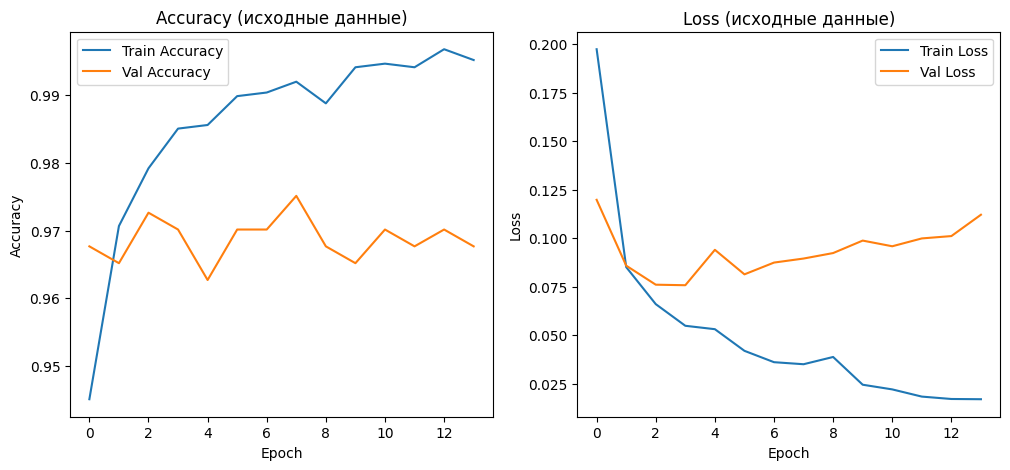

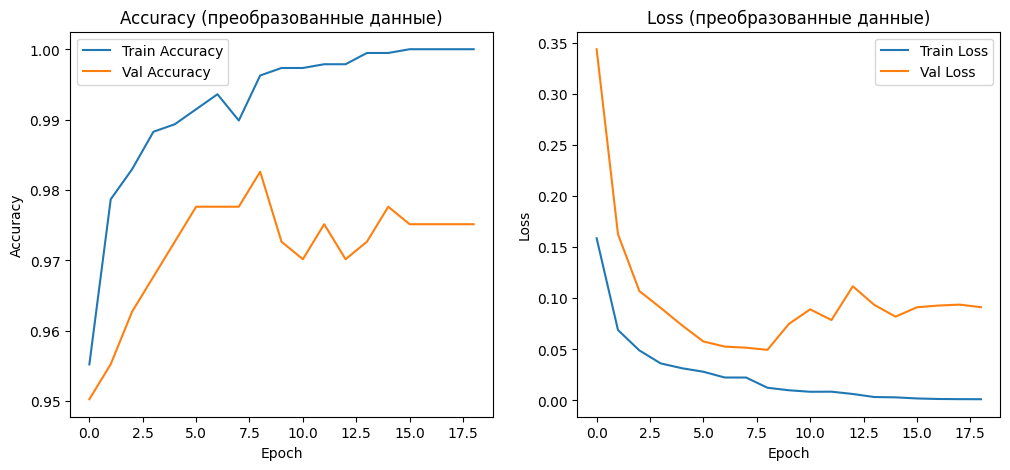

In [147]:
# Графики для исходных данных
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_raw.history['accuracy'], label='Train Accuracy')
plt.plot(history_raw.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy (исходные данные)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_raw.history['loss'], label='Train Loss')
plt.plot(history_raw.history['val_loss'], label='Val Loss')
plt.title('Loss (исходные данные)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


# Графики для преобразованных данных
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_scaled.history['accuracy'], label='Train Accuracy')
plt.plot(history_scaled.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy (преобразованные данные)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_scaled.history['loss'], label='Train Loss')
plt.plot(history_scaled.history['val_loss'], label='Val Loss')
plt.title('Loss (преобразованные данные)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

На графиках представлена динамика изменения точности (accuracy) и функции потерь (loss) на обучающей и валидационной выборках для моделей, обученных на исходных и преобразованных данных.

Для модели, обученной на исходных данных, наблюдается устойчивый рост точности на обучающей выборке и постепенное снижение функции потерь. При этом точность на валидационной выборке после первых эпох стабилизируется и изменяется незначительно, тогда как значение val_loss после начального снижения начинает возрастать. Это указывает на появление признаков переобучения на более поздних эпохах.

Для модели, обученной на преобразованных данных, также наблюдается уверенная сходимость: точность на обучающей выборке быстро возрастает, а функция потерь уменьшается. На валидационной выборке достигаются более высокие значения точности и более низкие значения функции потерь по сравнению с моделью на исходных данных. Вместе с тем после достижения наилучшего качества на ранних эпохах также проявляется рост val_loss, что свидетельствует о начале переобучения.

Сравнение графиков показывает, что модель на преобразованных данных обучается более эффективно и демонстрирует лучшее качество обобщения. Это подтверждает целесообразность использования стандартизованного набора данных на последующих этапах работы.

###9.2 Предсказания модели

In [148]:
# Предсказания (исходные данные)
y_pred_raw = baseline_model_raw.predict(X_test_cnn)
y_pred_raw_classes = y_pred_raw.argmax(axis=1)

# Предсказания (преобразованные данные)
y_pred_scaled = baseline_model_scaled.predict(X_test_scaled_cnn)
y_pred_scaled_classes = y_pred_scaled.argmax(axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


Предсказание выполняется пакетно на тестовой выборке объёмом 402 объекта, что в данном случае соответствует 13 батчам. Для каждого объекта модель вычисляет вероятности принадлежности к трём классам, после чего итоговый класс определяется по максимальной вероятности. Полученные предсказания далее используются для расчёта метрик качества, построения матриц ошибок и анализа результатов классификации.

###9.3 Основные метрики качества

Classification report (исходные данные):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       353
           1       0.94      0.94      0.94        33
           2       0.79      0.69      0.73        16

    accuracy                           0.98       402
   macro avg       0.90      0.87      0.89       402
weighted avg       0.98      0.98      0.98       402



Classification report (преобразованные данные):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       353
           1       0.94      0.91      0.92        33
           2       0.75      0.75      0.75        16

    accuracy                           0.98       402
   macro avg       0.89      0.88      0.89       402
weighted avg       0.98      0.98      0.98       402



Сравнительная таблица метрик качества:


,Метрика,Исходные данные,Преобразованные данные,Лучшая модель
,Accuracy,0.9776,0.9776,Одинаково
,Balanced Accuracy,0.8737,0.8845,Преобразованные данные
,Precision,0.9766,0.9775,Преобразованные данные
,Recall,0.9776,0.9776,Одинаково
,F1-score,0.9770,0.9775,Преобразованные данные
,ROC-AUC,0.9979,0.9985,Преобразованные данные


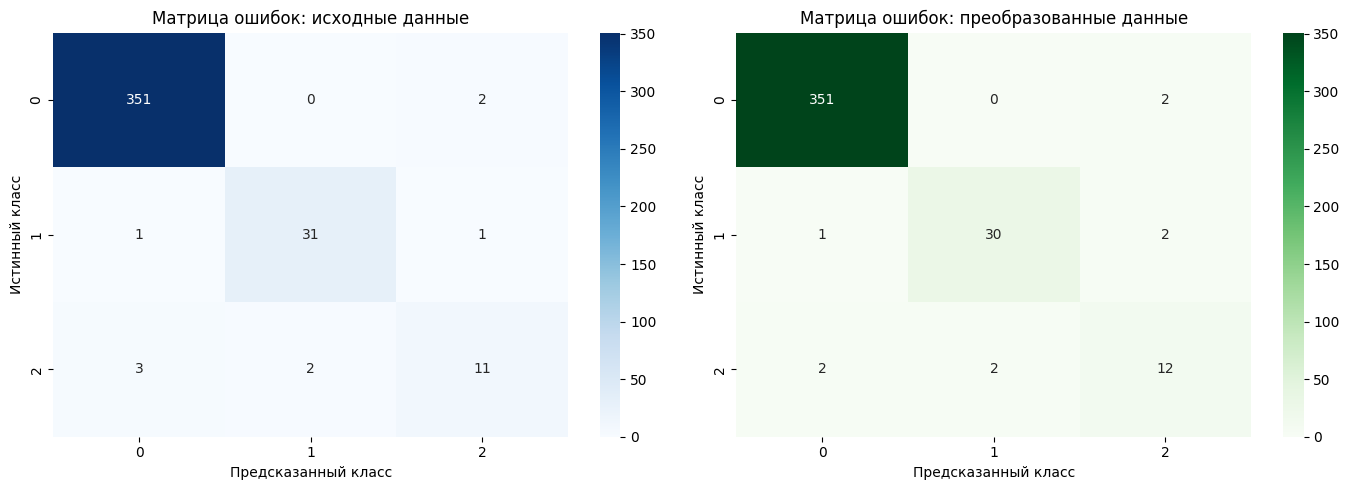

In [149]:
print("Classification report (исходные данные):")
print(classification_report(y_test, y_pred_raw_classes))

print("\n\nClassification report (преобразованные данные):")
print(classification_report(y_test, y_pred_scaled_classes))

# Вычисление основных метрик для исходных данных
metrics_raw = {
    "Accuracy": accuracy_score(y_test, y_pred_raw_classes),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_raw_classes),
    "Precision": precision_score(y_test, y_pred_raw_classes, average="weighted"),
    "Recall": recall_score(y_test, y_pred_raw_classes, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_raw_classes, average="weighted"),
    "ROC-AUC": roc_auc_score(
        label_binarize(y_test, classes=np.unique(y_test)),
        y_pred_raw,
        multi_class="ovr",
        average="weighted"
    )
}

# Вычисление основных метрик для преобразованных данных
metrics_scaled = {
    "Accuracy": accuracy_score(y_test, y_pred_scaled_classes),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_scaled_classes),
    "Precision": precision_score(y_test, y_pred_scaled_classes, average="weighted"),
    "Recall": recall_score(y_test, y_pred_scaled_classes, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_scaled_classes, average="weighted"),
    "ROC-AUC": roc_auc_score(
        label_binarize(y_test, classes=np.unique(y_test)),
        y_pred_scaled,
        multi_class="ovr",
        average="weighted"
    )
}

# Формирование сравнительной таблицы метрик
metrics_table = pd.DataFrame({
    "Метрика": list(metrics_raw.keys()),
    "Исходные данные": list(metrics_raw.values()),
    "Преобразованные данные": list(metrics_scaled.values())
})

def get_best_model(row):
    if row["Преобразованные данные"] > row["Исходные данные"]:
        return "Преобразованные данные"
    if row["Преобразованные данные"] < row["Исходные данные"]:
        return "Исходные данные"
    return "Одинаково"

metrics_table["Лучшая модель"] = metrics_table.apply(get_best_model, axis=1)

metrics_table["Исходные данные"] = metrics_table["Исходные данные"].round(4)
metrics_table["Преобразованные данные"] = metrics_table["Преобразованные данные"].round(4)

metrics_table.index = [""] * len(metrics_table)

print("\n\nСравнительная таблица метрик качества:")
display(metrics_table)
print()
print()

# Матрицы ошибок
cm_raw = confusion_matrix(y_test, y_pred_raw_classes)
cm_scaled = confusion_matrix(y_test, y_pred_scaled_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Матрица ошибок: исходные данные")
axes[0].set_xlabel("Предсказанный класс")
axes[0].set_ylabel("Истинный класс")

sns.heatmap(cm_scaled, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Матрица ошибок: преобразованные данные")
axes[1].set_xlabel("Предсказанный класс")
axes[1].set_ylabel("Истинный класс")

plt.tight_layout()
plt.show()

По результатам оценки качества видно, что обе модели демонстрируют высокую общую точность классификации: значение Accuracy в обоих случаях составляет 0.9776. Однако для данной задачи эта метрика не является определяющей, поскольку распределение классов является несбалансированным: основную часть выборки составляет класс 0, соответствующий штатному функционированию, тогда как классы 1 и 2, отражающие неисправности, представлены значительно меньшим числом объектов. В условиях такого дисбаланса высокая Accuracy может быть достигнута даже при недостаточно качественном распознавании нештатных состояний.

По этой причине более информативными являются метрики Balanced Accuracy, Precision, F1-score и ROC-AUC, а также значения precision, recall и f1-score для классов 1 и 2 в classification report. С этой точки зрения модель, обученная на преобразованных данных, показывает более предпочтительный результат. Значение Balanced Accuracy увеличивается с 0.8737 до 0.8845, F1-score — с 0.9770 до 0.9775, а ROC-AUC — с 0.9979 до 0.9985. Это свидетельствует о более сбалансированном качестве распознавания по всем классам.

Особое внимание следует уделить классам 1 и 2, поскольку именно они соответствуют отказам и сбоям, а значит, имеют наибольшую практическую значимость в задаче диагностики технического состояния МКА. Для класса 1 модель на исходных данных показывает немного лучшие результаты: recall = 0.94 и f1-score = 0.94, тогда как для преобразованных данных эти значения составляют 0.91 и 0.92 соответственно. Однако для класса 2, который также относится к нештатным состояниям, модель на преобразованных данных оказывается лучше: recall возрастает с 0.69 до 0.75, а f1-score — с 0.73 до 0.75. С практической точки зрения это является важным преимуществом, поскольку модель начинает лучше обнаруживать редкий класс неисправности.

Анализ матриц ошибок подтверждает данный вывод. В обоих случаях класс 0 распознаётся практически безошибочно: из 353 объектов верно классифицировано 351. Для класса 1 модель на исходных данных допускает 2 ошибки, а на преобразованных — 3 ошибки. Для класса 2 модель на исходных данных правильно определяет 11 из 16 объектов, тогда как на преобразованных данных — 12 из 16. Таким образом, преобразование данных позволило улучшить распознавание класса 2, не ухудшив при этом качество классификации в целом.

Следовательно, несмотря на одинаковое значение общей точности, модель на преобразованных данных является более предпочтительной для дальнейшего использования, поскольку при несбалансированном распределении классов она обеспечивает более высокое значение Balanced Accuracy и лучше выявляет нештатные состояния, прежде всего объекты класса 2. Именно поэтому на последующих этапах работы целесообразно использовать преобразованный набор данных.

###9.4 Вывод

По итогам сравнения установлено, что модель на преобразованных данных показывает более предпочтительные результаты, чем модель на исходных данных. При одинаковом значении Accuracy она имеет более высокие значения Balanced Accuracy, F1-score и ROC-AUC, а также лучше распознаёт редкие классы неисправностей. Поэтому для дальнейшей работы выбран преобразованный набор данных.

##10. Генетический алгоритм подбора гиперпараметров

###10.1 Определение гиперпараметров

Для оптимизации выбираются следующие параметры модели:
- количество фильтров в первом и втором сверточных слоях (`filters_1`, `filters_2`);
- размер ядра свёртки для первого и второго слоёв (`kernel_size_1`, `kernel_size_2`);
- количество нейронов в GRU (`gru_units`);
- количество нейронов в полносвязном слое (`dense_units`);
- коэффициент dropout (`dropout`);
- learning rate;
- размер батча (`batch_size`).

Каждый набор параметров будет представлять собой особь в генетическом алгоритме.

###10.2 Определение пространства поиска

In [150]:
param_space = {
    "filters_1": [32, 64, 128],
    "kernel_size_1": [2, 3, 5],
    "filters_2": [64, 128, 256],
    "kernel_size_2": [2, 3, 5],
    "gru_units": [32, 64, 128],
    "dense_units": [32, 64, 128],
    "dropout": [0.2, 0.3, 0.5],
    "learning_rate": [1e-3, 5e-4, 1e-4],
    "batch_size": [16, 32, 64]
}

Таким образом, определено пространство поиска генетического алгоритма, включающее возможные значения архитектурных и обучающих гиперпараметров модели. Это пространство используется для случайной генерации начальной популяции и последующего поиска наиболее эффективной конфигурации CNN + GRU модели.

###10.3 Генерация начальной популяции

In [151]:
def create_individual():
    return {
        "filters_1": random.choice(param_space["filters_1"]),
        "kernel_size_1": random.choice(param_space["kernel_size_1"]),
        "filters_2": random.choice(param_space["filters_2"]),
        "kernel_size_2": random.choice(param_space["kernel_size_2"]),
        "gru_units": random.choice(param_space["gru_units"]),
        "dense_units": random.choice(param_space["dense_units"]),
        "dropout": random.choice(param_space["dropout"]),
        "learning_rate": random.choice(param_space["learning_rate"]),
        "batch_size": random.choice(param_space["batch_size"])
    }

def create_population(size=10):
    return [create_individual() for _ in range(size)]

population = create_population()
# пример двух особей начальной популяции
print(population[:2])

[{'filters_1': 128, 'kernel_size_1': 5, 'filters_2': 64, 'kernel_size_2': 2, 'gru_units': 64, 'dense_units': 64, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 64}, {'filters_1': 128, 'kernel_size_1': 5, 'filters_2': 64, 'kernel_size_2': 5, 'gru_units': 64, 'dense_units': 64, 'dropout': 0.5, 'learning_rate': 0.0001, 'batch_size': 64}]


Начальная популяция формируется случайным образом.

Каждая особь представляет собой набор гиперпараметров модели.

Случайная инициализация позволяет обеспечить разнообразие решений и избежать преждевременной сходимости алгоритма.

###10.4 Функция оценки (fitness)

In [152]:
def fitness_function(params):
    model = build_baseline_cnn_gru_model(
        input_shape=X_train_scaled_cnn.shape[1:],
        num_classes=len(np.unique(y_train)),
        params=params
    )

    model.fit(
        X_train_scaled_cnn,
        y_train,
        validation_data=(X_val_scaled_cnn, y_val),
        epochs=10,
        batch_size=params["batch_size"],
        verbose=0,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
        ]
    )

    y_val_pred = model.predict(X_val_scaled_cnn, verbose=0)
    y_val_pred_classes = y_val_pred.argmax(axis=1)

    score = balanced_accuracy_score(y_val, y_val_pred_classes)
    return score

Для оценки качества особей в генетическом алгоритме используется функция приспособленности (fitness function). Каждая особь представляет собой конкретную комбинацию гиперпараметров модели:

- числа фильтров в сверточных слоях;
- размеров ядер свёртки;
- числа нейронов в GRU-слое;
- числа нейронов полносвязного слоя;
- коэффициента Dropout;
- скорости обучения;
- размера батча.

Для каждой особи строится и обучается нейросетевая модель на обучающей выборке, после чего рассчитывается качество на валидационной выборке. В текущей реализации в качестве значения функции приспособленности используется максимальная точность классификации на валидационной выборке (max(val_accuracy)), достигнутая в процессе обучения. Это позволяет выбирать такие комбинации гиперпараметров, которые обеспечивают наилучшее качество модели на независимой валидационной подвыборке.

При этом, поскольку задача классификации является несбалансированной, при интерпретации результатов генетического алгоритма дополнительно анализируются метрики Balanced Accuracy, F1-score и ROC-AUC, которые лучше отражают качество распознавания миноритарных классов.

###10.5 Операторы генетического алгоритма

In [153]:
def tournament_selection(population, scores, tournament_size=3):
    selected = []
    for _ in range(2):
        tournament_indices = np.random.choice(len(population), tournament_size, replace=False)
        tournament_scores = [scores[i] for i in tournament_indices]
        winner_idx = tournament_indices[np.argmax(tournament_scores)]
        selected.append(population[winner_idx])
    return selected[0], selected[1]

def crossover(parent1, parent2):
    child = {}
    for key in param_space.keys():
        child[key] = random.choice([parent1[key], parent2[key]])
    return child

def mutation(individual, mutation_rate=0.2):
    for key in param_space.keys():
        if random.random() < mutation_rate:
            individual[key] = random.choice(param_space[key])
    return individual

В генетическом алгоритме используются следующие операторы:

- tournament_selection — отбор лучших особей с помощью турнирного отбора;
- crossover — скрещивание двух родителей;
- mutation — случайное изменение параметров.

Эти операторы обеспечивают эволюционное улучшение популяции и поиск оптимальных гиперпараметров модели.

###10.6 Основной цикл алгоритма

In [155]:
ga_log = []
n_generations = 5
population_size = 8
elite_size = 2

population = create_population(population_size)

best_overall_score = -1
best_overall_params = None

for generation in range(n_generations):
    print(f"Поколение {generation + 1}")

    scores = [fitness_function(ind) for ind in population]

    for individual, score in zip(population, scores):
        ga_log.append({
            "generation": generation + 1,
            "filters_1": individual["filters_1"],
            "kernel_size_1": individual["kernel_size_1"],
            "filters_2": individual["filters_2"],
            "kernel_size_2": individual["kernel_size_2"],
            "gru_units": individual["gru_units"],
            "dense_units": individual["dense_units"],
            "dropout": individual["dropout"],
            "learning_rate": individual["learning_rate"],
            "batch_size": individual["batch_size"],
            "val_balanced_accuracy": score
        })

    generation_best_idx = np.argmax(scores)
    generation_best_score = scores[generation_best_idx]
    generation_best_params = population[generation_best_idx]

    if generation_best_score > best_overall_score:
        best_overall_score = generation_best_score
        best_overall_params = generation_best_params.copy()

    elite_indices = np.argsort(scores)[-elite_size:]
    elites = [population[i].copy() for i in elite_indices]

    new_population = elites.copy()

    while len(new_population) < population_size:
        parent1, parent2 = tournament_selection(population, scores)

        child = crossover(parent1, parent2)
        child = mutation(child)

        new_population.append(child)

    population = new_population

print("Лучшие параметры:", best_overall_params)
print("Лучшее значение Balanced Accuracy на валидации:", best_overall_score)

ga_log_df = pd.DataFrame(ga_log)
ga_log_df.to_csv("ga_model_log.csv", index=False)

best_params = best_overall_params

best_ga_model = build_baseline_cnn_gru_model(
    input_shape=X_train_scaled_cnn.shape[1:],
    num_classes=len(np.unique(y_train)),
    params=best_params
)

early_stopping_ga = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr_ga = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history_ga = best_ga_model.fit(
    X_train_scaled_cnn,
    y_train,
    validation_data=(X_val_scaled_cnn, y_val),
    epochs=50,
    batch_size=best_params["batch_size"],
    callbacks=[early_stopping_ga, reduce_lr_ga],
    verbose=1
)

y_pred_ga = best_ga_model.predict(X_test_scaled_cnn, verbose=0)
y_pred_ga_classes = y_pred_ga.argmax(axis=1)

print("\n\nClassification report (GA):")
print(classification_report(y_test, y_pred_ga_classes))

print("\n\nAccuracy (GA):", round(accuracy_score(y_test, y_pred_ga_classes), 4))
print("Balanced Accuracy (GA):", round(balanced_accuracy_score(y_test, y_pred_ga_classes), 4))
print("Precision (GA):", round(precision_score(y_test, y_pred_ga_classes, average="weighted"), 4))
print("Recall (GA):", round(recall_score(y_test, y_pred_ga_classes, average="weighted"), 4))
print("F1-score (GA):", round(f1_score(y_test, y_pred_ga_classes, average="weighted"), 4))
print("ROC-AUC (GA):", round(roc_auc_score(
    label_binarize(y_test, classes=np.unique(y_test)),
    y_pred_ga,
    multi_class="ovr",
    average="weighted"
), 4))

Поколение 1
Поколение 2
Поколение 3
Поколение 4
Поколение 5
Лучшие параметры: {'filters_1': 128, 'kernel_size_1': 2, 'filters_2': 64, 'kernel_size_2': 5, 'gru_units': 128, 'dense_units': 128, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 16}
Лучшее значение Balanced Accuracy на валидации: 0.9545668549905838
Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9552 - loss: 0.1264 - val_accuracy: 0.9726 - val_loss: 0.0910 - learning_rate: 0.0010
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9771 - loss: 0.0665 - val_accuracy: 0.9701 - val_loss: 0.0681 - learning_rate: 0.0010
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9808 - loss: 0.0500 - val_accuracy: 0.9701 - val_loss: 0.0661 - learning_rate: 0.0010
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9835 - loss: 0.0407 - val_accuracy: 0.9726 - val_loss: 0.0762 - learning_rate: 0.0010
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9904

В ходе работы генетического алгоритма был выполнен поиск конфигурации гиперпараметров CNN + GRU модели в заданном пространстве поиска. Для каждой особи в качестве функции приспособленности использовалось значение Balanced Accuracy на валидационной выборке, что особенно важно в условиях несбалансированного распределения классов. Дополнительно в алгоритм был использован механизм элитизма, позволяющий сохранять лучшие решения каждого поколения и тем самым снижать риск потери удачных конфигураций в процессе эволюционного поиска.

По результатам работы алгоритма была выбрана конфигурация гиперпараметров, обеспечившая наилучшее значение Balanced Accuracy на валидационной выборке, равное 0.9546. На основе найденных параметров была построена итоговая модель, которая затем была повторно обучена на обучающей выборке с контролем качества на валидационной выборке с использованием механизмов EarlyStopping и ReduceLROnPlateau.

Анализ динамики обучения показывает, что модель демонстрирует устойчивую сходимость: точность на обучающей выборке быстро возрастает и на поздних эпохах достигает значений, близких к 1.0, тогда как качество на валидационной выборке остаётся стабильно высоким. При этом после первых эпох наблюдается увеличение разрыва между обучающими и валидационными показателями, что указывает на появление признаков переобучения. Наиболее удачные результаты на валидационной выборке достигаются на ранних этапах обучения.

По результатам тестирования итоговой модели получены следующие значения метрик: Accuracy = 0.9776, Balanced Accuracy = 0.8936, Precision = 0.9785, Recall = 0.9776, F1-score = 0.9780, ROC-AUC = 0.9985. Несмотря на высокое значение общей точности и ROC-AUC, для данной задачи наибольшее значение имеет качество распознавания миноритарных классов 1 и 2, соответствующих неисправным состояниям МКА.

Согласно classification report, итоговая модель после подбора гиперпараметров демонстрирует хорошее качество распознавания класса 1 (precision = 0.91, recall = 0.94, f1-score = 0.93). Для класса 2 качество ниже, однако остаётся приемлемым: precision = 0.71, recall = 0.75, f1-score = 0.73. Это означает, что модель способна выявлять объекты редкого класса неисправности, хотя точность их распознавания всё ещё уступает качеству классификации доминирующего класса 0.

Для более наглядного сопоставления результатов ниже приведена сравнительная таблица трёх рассмотренных моделей: модели, обученной на исходных данных, модели, обученной на преобразованных данных, и модели, полученной после подбора гиперпараметров с помощью генетического алгоритма.

Основные результаты:

| Метрика | Исходные данные | Преобразованные данные | Модель после ГА | Лучшая модель |
|---------|-----------------|------------------------|-----------------|---------------|
| Accuracy | 0.9776 | 0.9776 | 0.9776 | Одинаково |
| Balanced Accuracy | 0.8737 | 0.8845 | 0.8936 | Модель после ГА |
| Precision | 0.9766 | 0.9775 | 0.9785 | Модель после ГА |
| Recall | 0.9776 | 0.9776 | 0.9776 | Одинаково |
| F1-score | 0.9770 | 0.9775 | 0.9780 | Модель после ГА |
| ROC-AUC | 0.9979 | 0.9985 | 0.9985 | Преобразованные данные, Модель после ГА |

Из приведённой таблицы видно, что модель после подбора гиперпараметров с помощью генетического алгоритма показывает наилучшее значение Balanced Accuracy, а также немного превосходит остальные модели по Precision и F1-score. Значение ROC-AUC для модели после ГА совпадает с лучшим результатом, полученным на преобразованных данных. Следовательно, генетический алгоритм позволил подобрать более эффективную конфигурацию гиперпараметров, чем в исходной базовой модели, особенно с точки зрения качества классификации в условиях несбалансированного распределения классов.

###10.7 Вывод

В результате применения генетического алгоритма была найдена конфигурация гиперпараметров CNN + GRU модели, обеспечившая высокое качество классификации на валидационной и тестовой выборках. Анализ итоговых метрик показал, что полученная модель демонстрирует улучшение по наиболее важной для данной задачи метрике Balanced Accuracy по сравнению с базовой моделью на преобразованных данных, а также сохраняет высокие значения F1-score и ROC-AUC. Следовательно, генетический алгоритм позволил подобрать более эффективную конфигурацию гиперпараметров модели, которая может быть использована в качестве основы для следующего этапа работы — предобучения с помощью автокодировщика на неразмеченных данных.

##11. Предобучение базовой нейронной сети с помощью автокодировщика и её последующее дообучение

###11.1 Идея метода

В соответствии с заданием на неразмеченной части набора данных необходимо выполнить предобучение с помощью автокодировщика, построенного на основании базового нейросетевого классификатора, а затем выполнить дообучение базовой сети на размеченном наборе данных.

Для варианта 2 базовая модель представляет собой сеть с последовательным соединением одномерных сверточных слоёв и слоя GRU. Поэтому в данной работе используется автокодировщик, кодировщик которого повторяет нижнюю часть базового классификатора. После обучения автокодировщика на неразмеченных данных веса кодировщика переносятся в классификационную модель, после чего выполняется её дообучение на размеченной выборке.

Поскольку ранее было показано, что преобразованные данные обеспечивают более качественные результаты, предобучение и последующее дообучение выполняются на стандартизованном наборе данных.

###11.2 Построение и обучение автокодировщика

Автокодировщик состоит из двух частей: кодировщика и декодировщика. Кодировщик включает два одномерных сверточных слоя, два слоя подвыборки и слой GRU, формирующий компактное скрытое представление входного объекта. Декодировщик восстанавливает исходную последовательность признаков по этому скрытому представлению.

Такая архитектура соответствует логике лекции: сначала модель обучается восстанавливать входные данные без использования меток классов, после чего кодирующая часть используется в задаче классификации.

In [163]:
input_shape = X_train_scaled_cnn.shape[1:]
num_classes = len(np.unique(y_train))

def build_cnn_gru_autoencoder(input_shape):
    ae_input = Input(shape=input_shape, name="ae_input")

    x = Conv1D(64, kernel_size=3, padding="same", activation="relu", name="encoder_conv1")(ae_input)
    x = MaxPooling1D(pool_size=2, name="encoder_pool1")(x)

    x = Conv1D(128, kernel_size=3, padding="same", activation="relu", name="encoder_conv2")(x)
    x = MaxPooling1D(pool_size=2, name="encoder_pool2")(x)

    encoded = GRU(32, name="encoder_gru")(x)

    x = RepeatVector(input_shape[0], name="decoder_repeat")(encoded)
    x = GRU(32, return_sequences=True, name="decoder_gru")(x)
    x = TimeDistributed(Dense(32, activation="relu"), name="decoder_dense")(x)
    decoded = TimeDistributed(Dense(1, activation="linear"), name="decoder_output")(x)

    autoencoder = Model(ae_input, decoded, name="cnn_gru_autoencoder")
    autoencoder.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return autoencoder

autoencoder = build_cnn_gru_autoencoder(input_shape)
autoencoder.summary()

early_stopping_ae = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr_ae = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

checkpoint_ae = ModelCheckpoint(
    filepath="best_autoencoder.keras",
    monitor="val_loss",
    save_best_only=True
)

history_ae = autoencoder.fit(
    X_unlabeled_scaled_cnn,
    X_unlabeled_scaled_cnn,
    validation_data=(X_val_scaled_cnn, X_val_scaled_cnn),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_ae, reduce_lr_ae, checkpoint_ae],
    verbose=1
)

Model: "cnn_gru_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 49, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv1 (Conv1D)          │ (None, 49, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool1 (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv2 (Conv1D)          │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool2 (MaxPooling1D)    │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_gru (GRU)               │ (None, 32)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_repeat (RepeatVector)   │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_gru (GRU)               │ (None, 49, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense (TimeDistributed) │ (None, 49, 32)         │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output                  │ (None, 49, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,937 (187.25 KB)

 Trainable params: 47,937 (187.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - loss: 0.2675 - val_loss: 0.4545 - learning_rate: 0.0010
Epoch 2/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.2233 - val_loss: 0.3885 - learning_rate: 0.0010
Epoch 3/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.2125 - val_loss: 0.3766 - learning_rate: 0.0010
Epoch 4/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.2041 - val_loss: 0.3609 - learning_rate: 0.0010
Epoch 5/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1949 - val_loss: 0.3782 - learning_rate: 0.0010
Epoch 6/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.1884 - val_loss: 0.3663 - learning_rate: 0.0010
Epoch 7/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.1826 - val_loss: 0.3367 - learning_rate: 0.0010
Epoch 8/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.1781 - val_loss: 0.3310 - learning_rate: 0.0010
Epoch 9/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.1750 - val_loss: 0.3273 - learning_rate: 0.0010


В результате построения автокодировщика получена модель, принимающая на вход последовательность размерности (49, 1) и восстанавливающая её после прохождения через компактное скрытое представление. Кодировщик включает два сверточных слоя, два слоя подвыборки и слой GRU, в котором формируется латентный вектор размерности 32. Следовательно, на этапе кодирования исходный объект сжимается до 32-мерного скрытого представления, содержащего наиболее существенные особенности входных телеметрических данных.

По структуре модели видно, что после первого сверточного слоя число каналов увеличивается до 64, после второго — до 128, а после последовательного применения операций подвыборки длина последовательности уменьшается с 49 до 12. Далее слой GRU(32) преобразует полученное представление в компактный вектор фиксированной размерности. В декодировщике этот вектор используется для восстановления исходной последовательности признаков.

Результаты обучения показывают устойчивую сходимость автокодировщика. Значение функции потерь на обучающей выборке последовательно уменьшается с 0.2675 на первой эпохе до 0.1327 на последней эпохе. Аналогично значение функции потерь на валидационной выборке снижается с 0.4545 до значений порядка 0.2674–0.2769, а наименьшее значение val_loss достигается на 47-й эпохе и составляет 0.2674. Это свидетельствует о том, что модель постепенно улучшает качество восстановления входных данных и успешно извлекает информативное скрытое представление неразмеченных объектов.

После 30-й эпохи произошло уменьшение скорости обучения с 0.0010 до 0.0005, что позволило стабилизировать процесс оптимизации и добиться дополнительного снижения функции потерь. При этом заметного расхождения между обучающей и валидационной ошибками не наблюдается, поэтому можно сделать вывод, что автокодировщик обучается устойчиво и без выраженных признаков переобучения.

Таким образом, этап предобучения автокодировщика можно считать успешным. Полученные веса кодировщика далее будут использованы при построении классификационной модели, которая затем будет дообучена на размеченном наборе данных для решения задачи распознавания технического состояния малого космического аппарата.

###11.3 Построение классификатора на основе кодировщика

После предобучения автокодировщика формируется классификационная модель. В её состав включаются слои кодировщика, после которых располагаются полносвязный слой, слой Dropout и выходной слой softmax, выполняющий многоклассовую классификацию состояний МКА.

In [164]:
def build_pretrained_classifier(input_shape, num_classes):
    clf_input = Input(shape=input_shape, name="clf_input")

    x = Conv1D(64, kernel_size=3, padding="same", activation="relu", name="encoder_conv1")(clf_input)
    x = MaxPooling1D(pool_size=2, name="encoder_pool1")(x)

    x = Conv1D(128, kernel_size=3, padding="same", activation="relu", name="encoder_conv2")(x)
    x = MaxPooling1D(pool_size=2, name="encoder_pool2")(x)

    x = GRU(32, name="encoder_gru")(x)

    x = Dense(64, activation="relu", name="dense_classifier")(x)
    x = Dropout(0.3, name="dropout_classifier")(x)
    output = Dense(num_classes, activation="softmax", name="output_classifier")(x)

    classifier = Model(clf_input, output, name="pretrained_cnn_gru_classifier")
    return classifier

pretrained_classifier = build_pretrained_classifier(input_shape, num_classes)

for layer_name in ["encoder_conv1", "encoder_conv2", "encoder_gru"]:
    pretrained_classifier.get_layer(layer_name).set_weights(
        autoencoder.get_layer(layer_name).get_weights()
    )

pretrained_classifier.summary()

Model: "pretrained_cnn_gru_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ clf_input (InputLayer)          │ (None, 49, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv1 (Conv1D)          │ (None, 49, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool1 (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv2 (Conv1D)          │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool2 (MaxPooling1D)    │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_gru (GRU)               │ (None, 32)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_classifier (Dense)        │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_classifier (Dropout)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_classifier (Dense)       │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,819 (167.26 KB)

 Trainable params: 42,819 (167.26 KB)

 Non-trainable params: 0 (0.00 B)

В результате была построена классификационная модель, основанная на предобученном кодировщике автокодировщика. Нижние слои сети сохраняют ранее сформированное представление телеметрических данных, а верхняя часть модели выполняет многоклассовую классификацию состояний МКА. Использование весов, полученных на неразмеченных данных, позволяет начать обучение классификатора с более информативной инициализации. На следующем этапе выполняется дообучение модели на размеченной выборке.

###11.4 Дообучение классификационной модели на размеченных данных

После переноса весов кодировщика классификационная модель дообучается на размеченном наборе данных. Для этого используется стандартная функция потерь многоклассовой классификации и механизмы регуляризации, ограничивающие переобучение.

In [165]:
pretrained_classifier.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_pretrained = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr_pretrained = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

checkpoint_pretrained = ModelCheckpoint(
    filepath="best_pretrained_classifier.keras",
    monitor="val_loss",
    save_best_only=True
)

history_pretrained = pretrained_classifier.fit(
    X_train_scaled_cnn,
    y_train,
    validation_data=(X_val_scaled_cnn, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_pretrained, reduce_lr_pretrained, checkpoint_pretrained],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8459 - loss: 0.4852 - val_accuracy: 0.9552 - val_loss: 0.1738 - learning_rate: 5.0000e-04
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9557 - loss: 0.1696 - val_accuracy: 0.9701 - val_loss: 0.0991 - learning_rate: 5.0000e-04
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9664 - loss: 0.1131 - val_accuracy: 0.9677 - val_loss: 0.0817 - learning_rate: 5.0000e-04
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9717 - loss: 0.0985 - val_accuracy: 0.9751 - val_loss: 0.0718 - learning_rate: 5.0000e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9760 - loss: 0.0813 - val_accuracy: 0.9776 - val_loss: 0.0671 - learning_rate: 5.0000e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9760 - loss: 0.0714 - val_accuracy: 0.9801 - val_loss: 0.0626 - learning_rate: 5.0000e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9792 

В процессе дообучения классификационная модель, инициализированная весами кодировщика автокодировщика, демонстрирует устойчивую сходимость. Уже на первой эпохе точность на валидационной выборке составляет 0.9552, а далее быстро возрастает и достигает 0.9826 на 7-й эпохе. Это показывает, что предварительно обученный кодировщик обеспечивает модели удачную начальную инициализацию и позволяет быстрее перейти к области хороших решений.

Точность на обучающей выборке последовательно увеличивается с 0.8459 до 0.9941, а значение функции потерь уменьшается с 0.4852 до 0.0189, что свидетельствует об эффективном обучении модели на размеченных данных. Одновременно значение val_loss на валидационной выборке снижается с 0.1738 до минимального значения 0.0575 на 11-й эпохе, после чего начинает постепенно возрастать. Такое поведение указывает на появление признаков переобучения на более поздних эпохах.

После 16-й эпохи произошло уменьшение скорости обучения с 0.0005 до 0.00025, что позволило стабилизировать дальнейшую настройку сети, однако существенного улучшения качества на валидационной выборке после этого уже не наблюдается. Следовательно, наиболее удачные веса модели были получены на ранних эпохах, ориентировочно в интервале 7–11 эпох, где достигаются наилучшие значения val_accuracy и val_loss.

Таким образом, этап дообучения классификационной модели можно считать успешным. Предварительное обучение с помощью автокодировщика позволило получить качественную начальную настройку сети, а последующее обучение на размеченных данных обеспечило высокое качество классификации. Окончательная оценка эффективности данного подхода будет выполнена на тестовой выборке и сопоставлена с результатами ранее рассмотренных моделей.

###11.5 Оценка качества модели и сравнение с предыдущими моделями

После завершения дообучения модель тестируется на тестовой выборке. Для оценки качества используются те же метрики, что и ранее: Accuracy, Balanced Accuracy, Precision, Recall, F1-score, ROC-AUC, а также classification report и матрица ошибок. Это позволяет корректно сравнить новую модель с моделью на исходных данных и моделью на преобразованных данных.

Classification report (предобученная модель):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       353
           1       0.97      0.94      0.95        33
           2       0.72      0.81      0.76        16

    accuracy                           0.98       402
   macro avg       0.89      0.91      0.90       402
weighted avg       0.98      0.98      0.98       402


Accuracy (предобученная модель): 0.97761
Balanced Accuracy (предобученная модель): 0.91352
Precision (предобученная модель): 0.97889
Recall (предобученная модель): 0.97761
F1-score (предобученная модель): 0.97813
ROC-AUC (предобученная модель): 0.99843




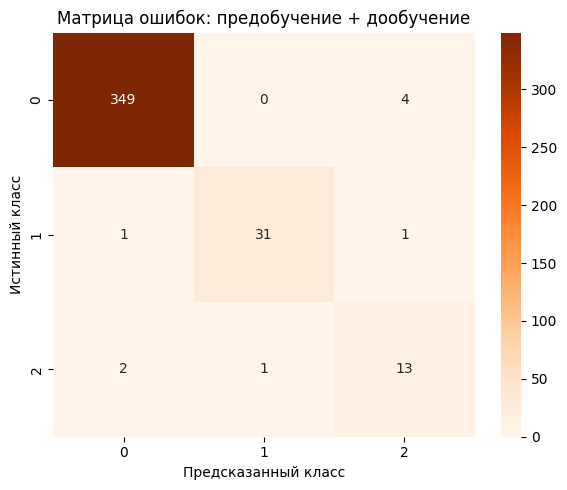



Сравнение четырёх моделей:


Метрика,Исходные данные,Преобразованные данные,Модель после ГА,Предобучение + дообучение,Лучшая модель
Accuracy,0.977610,0.977610,0.977610,0.977610,"Исходные данные, Преобразованные данные, Модель после ГА, Предобучение + дообучение"
Balanced Accuracy,0.873740,0.884480,0.893630,0.913520,Предобучение + дообучение
Precision,0.976600,0.977480,0.978550,0.978890,Предобучение + дообучение
Recall,0.977610,0.977610,0.977610,0.977610,"Исходные данные, Преобразованные данные, Модель после ГА, Предобучение + дообучение"
F1-score,0.976970,0.977530,0.978030,0.978130,Предобучение + дообучение
ROC-AUC,0.997870,0.998540,0.998470,0.998430,Преобразованные данные


In [166]:
y_pred_pretrained = pretrained_classifier.predict(X_test_scaled_cnn, verbose=0)
y_pred_pretrained_classes = y_pred_pretrained.argmax(axis=1)

print("Classification report (предобученная модель):")
print(classification_report(y_test, y_pred_pretrained_classes))

accuracy_pretrained = accuracy_score(y_test, y_pred_pretrained_classes)
balanced_accuracy_pretrained = balanced_accuracy_score(y_test, y_pred_pretrained_classes)
precision_pretrained = precision_score(y_test, y_pred_pretrained_classes, average="weighted")
recall_pretrained = recall_score(y_test, y_pred_pretrained_classes, average="weighted")
f1_pretrained = f1_score(y_test, y_pred_pretrained_classes, average="weighted")
roc_auc_pretrained = roc_auc_score(
    label_binarize(y_test, classes=np.unique(y_test)),
    y_pred_pretrained,
    multi_class="ovr",
    average="weighted"
)

print("\nAccuracy (предобученная модель):", round(accuracy_pretrained, 5))
print("Balanced Accuracy (предобученная модель):", round(balanced_accuracy_pretrained, 5))
print("Precision (предобученная модель):", round(precision_pretrained, 5))
print("Recall (предобученная модель):", round(recall_pretrained, 5))
print("F1-score (предобученная модель):", round(f1_pretrained, 5))
print("ROC-AUC (предобученная модель):", round(roc_auc_pretrained, 5))

print()
print()
cm_pretrained = confusion_matrix(y_test, y_pred_pretrained_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pretrained, annot=True, fmt="d", cmap="Oranges")
plt.title("Матрица ошибок: предобучение + дообучение")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()

accuracy_raw = accuracy_score(y_test, y_pred_raw_classes)
balanced_accuracy_raw = balanced_accuracy_score(y_test, y_pred_raw_classes)
precision_raw = precision_score(y_test, y_pred_raw_classes, average="weighted")
recall_raw = recall_score(y_test, y_pred_raw_classes, average="weighted")
f1_raw = f1_score(y_test, y_pred_raw_classes, average="weighted")
roc_auc_raw = roc_auc_score(
    label_binarize(y_test, classes=np.unique(y_test)),
    y_pred_raw,
    multi_class="ovr",
    average="weighted"
)

accuracy_scaled = accuracy_score(y_test, y_pred_scaled_classes)
balanced_accuracy_scaled = balanced_accuracy_score(y_test, y_pred_scaled_classes)
precision_scaled = precision_score(y_test, y_pred_scaled_classes, average="weighted")
recall_scaled = recall_score(y_test, y_pred_scaled_classes, average="weighted")
f1_scaled = f1_score(y_test, y_pred_scaled_classes, average="weighted")
roc_auc_scaled = roc_auc_score(
    label_binarize(y_test, classes=np.unique(y_test)),
    y_pred_scaled,
    multi_class="ovr",
    average="weighted"
)

accuracy_ga = accuracy_score(y_test, y_pred_ga_classes)
balanced_accuracy_ga = balanced_accuracy_score(y_test, y_pred_ga_classes)
precision_ga = precision_score(y_test, y_pred_ga_classes, average="weighted")
recall_ga = recall_score(y_test, y_pred_ga_classes, average="weighted")
f1_ga = f1_score(y_test, y_pred_ga_classes, average="weighted")
roc_auc_ga = roc_auc_score(
    label_binarize(y_test, classes=np.unique(y_test)),
    y_pred_ga,
    multi_class="ovr",
    average="weighted"
)

comparison_table = pd.DataFrame({
    "Метрика": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Исходные данные": [
        accuracy_raw,
        balanced_accuracy_raw,
        precision_raw,
        recall_raw,
        f1_raw,
        roc_auc_raw
    ],
    "Преобразованные данные": [
        accuracy_scaled,
        balanced_accuracy_scaled,
        precision_scaled,
        recall_scaled,
        f1_scaled,
        roc_auc_scaled
    ],
    "Модель после ГА": [
        accuracy_ga,
        balanced_accuracy_ga,
        precision_ga,
        recall_ga,
        f1_ga,
        roc_auc_ga
    ],
    "Предобучение + дообучение": [
        accuracy_pretrained,
        balanced_accuracy_pretrained,
        precision_pretrained,
        recall_pretrained,
        f1_pretrained,
        roc_auc_pretrained
    ]
})

def get_best_model(row):
    values = {
        "Исходные данные": row["Исходные данные"],
        "Преобразованные данные": row["Преобразованные данные"],
        "Модель после ГА": row["Модель после ГА"],
        "Предобучение + дообучение": row["Предобучение + дообучение"]
    }
    max_value = max(values.values())
    best_models = [name for name, value in values.items() if value == max_value]
    return ", ".join(best_models)

comparison_table["Лучшая модель"] = comparison_table.apply(get_best_model, axis=1)

comparison_table["Исходные данные"] = comparison_table["Исходные данные"].round(5)
comparison_table["Преобразованные данные"] = comparison_table["Преобразованные данные"].round(5)
comparison_table["Модель после ГА"] = comparison_table["Модель после ГА"].round(5)
comparison_table["Предобучение + дообучение"] = comparison_table["Предобучение + дообучение"].round(5)

print("\n\nСравнение четырёх моделей:")
display(comparison_table.style.hide(axis="index"))


По результатам тестирования модель, полученная после предобучения автокодировщиком и последующего дообучения на размеченных данных, продемонстрировала высокое качество классификации. Значения основных метрик составили: Accuracy = 0.97761, Balanced Accuracy = 0.91352, Precision = 0.97889, Recall = 0.97761, F1-score = 0.97813, ROC-AUC = 0.99843. Эти результаты показывают, что использование неразмеченных данных на этапе предобучения позволило улучшить качество распознавания классов по сравнению с ранее рассмотренными моделями, особенно по метрикам, чувствительным к несбалансированности выборки.

Наибольший интерес для данной задачи представляют классы 1 и 2, соответствующие нештатным состояниям МКА. Согласно classification report, для класса 1 получены значения precision = 0.97, recall = 0.94, f1-score = 0.95, а для класса 2 — precision = 0.72, recall = 0.81, f1-score = 0.76. Это означает, что модель после предобучения не только сохраняет высокое качество распознавания доминирующего класса 0, но и лучше выявляет редкие классы неисправностей, что особенно важно для практической задачи диагностики.

Анализ матрицы ошибок подтверждает данный вывод. Для класса 0 правильно распознано 349 из 353 объектов, для класса 1 — 31 из 33, для класса 2 — 13 из 16. При этом число верно распознанных объектов класса 2 оказалось выше, чем в ранее рассмотренных моделях, что свидетельствует об улучшении качества обнаружения неисправных состояний.

Сравнительная таблица четырёх моделей показывает, что модель после предобучения и дообучения является наилучшей по метрикам Balanced Accuracy, Precision и F1-score. Это особенно важно, поскольку в условиях несбалансированного распределения классов именно Balanced Accuracy и F1-score позволяют более объективно оценить качество распознавания всех состояний, включая редкие неисправности. По метрике ROC-AUC наилучший результат сохраняется у модели на преобразованных данных, однако отличие от предобученной модели незначительно.

Следовательно, применение автокодировщика на неразмеченных данных с последующим дообучением классификатора на размеченной выборке оказалось эффективным. Такой подход позволил получить лучшую модель среди всех рассмотренных по наиболее значимым для данной задачи показателям качества, прежде всего по способности распознавать миноритарные классы неисправностей.

###11.6 Вывод

Предобучение с помощью автокодировщика и последующее дообучение классификационной модели на размеченных данных позволили получить наилучшие результаты по наиболее важным для данной задачи метрикам. Особенно важно, что данный подход улучшил качество распознавания миноритарных классов, соответствующих неисправным состояниям МКА. Следовательно, модель с предобучением и дообучением является наиболее предпочтительной для решения поставленной задачи.

##12. Общий вывод